Load csvs. 1 csv- one conversation. each row, one utterance. some consecutive speaker rows.

In [189]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

PROJECT_ROOT = Path.cwd()
WIRED_DIR = PROJECT_ROOT / "data" / "wired"

csv_paths = sorted(WIRED_DIR.glob("wired_*/*.csv"))

print(f"Found {len(csv_paths)} CSV files")
csv_paths[:10]

Found 105 CSV files


[PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_12.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_13.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_14.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_15.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_astro/wired_astro_16.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_12.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_13.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_14.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_15.csv'),
 PosixPath('/Users/yume/PycharmProjects/horizons_2/data/wired/wired_blockchain/wired_blockchain_

In [190]:
def parse_wired_path(path):
    """
    Example:
    data/wired/wired_astro/wired_astro_12.csv
    """
    folder_name = path.parent.name
    file_stem = path.stem

    video_id = re.sub(r"^wired_", "", folder_name)

    match = re.search(r"_(\d+)$", file_stem)
    file_number = int(match.group(1)) if match else None

    return {
        "dataset": "wired",
        "video_id": video_id,
        "file_number": file_number,
        "conversation_id": file_stem,
        "source_file": str(path.relative_to(PROJECT_ROOT))
    }

In [191]:
raw_frames = []

for path in csv_paths:
    df = pd.read_csv(path)
    metadata = parse_wired_path(path)

    # Preserve original within-file row order
    df["raw_row_id"] = np.arange(len(df))

    for column, value in metadata.items():
        df[column] = value

    raw_frames.append(df)

wired_raw = pd.concat(
    raw_frames,
    ignore_index=True,
    sort=False
)

wired_raw.shape

(6384, 10)

In [192]:
for path in csv_paths:
    try:
        df = pd.read_csv(path)
        print("OK:", path.name)
    except pd.errors.ParserError as error:
        print("ERROR:", path)
        print(error)

OK: wired_astro_12.csv
OK: wired_astro_13.csv
OK: wired_astro_14.csv
OK: wired_astro_15.csv
OK: wired_astro_16.csv
OK: wired_blockchain_12.csv
OK: wired_blockchain_13.csv
OK: wired_blockchain_14.csv
OK: wired_blockchain_15.csv
OK: wired_blockchain_16.csv
OK: wired_crispr_12.csv
OK: wired_crispr_13.csv
OK: wired_crispr_14.csv
OK: wired_crispr_15.csv
OK: wired_crispr_16.csv
OK: wired_dimension_12.csv
OK: wired_dimension_13.csv
OK: wired_dimension_14.csv
OK: wired_dimension_15.csv
OK: wired_dimension_16.csv
OK: wired_fractal_12.csv
OK: wired_fractal_13.csv
OK: wired_fractal_14.csv
OK: wired_fractal_15.csv
OK: wired_fractal_16.csv
OK: wired_gravity_12.csv
OK: wired_gravity_13.csv
OK: wired_gravity_14.csv
OK: wired_gravity_15.csv
OK: wired_gravity_16.csv
OK: wired_hacking_12.csv
OK: wired_hacking_13.csv
OK: wired_hacking_14.csv
OK: wired_hacking_15.csv
OK: wired_hacking_16.csv
OK: wired_infinity_12.csv
OK: wired_infinity_13.csv
OK: wired_infinity_14.csv
OK: wired_infinity_15.csv
OK: wired_i

In [193]:
schema_rows = []

for path in csv_paths:
    df = pd.read_csv(path)

    schema_rows.append({
        "source_file": path.name,
        "folder": path.parent.name,
        "n_rows": len(df),
        "columns": tuple(df.columns)
    })

schema_df = pd.DataFrame(schema_rows)

schema_df.head()

,source_file,folder,n_rows,columns
0,wired_astro_12.csv,wired_astro,56,"(Sequence, Speaker, Utterance, Notes)"
1,wired_astro_13.csv,wired_astro,53,"(Sequence, Speaker, Utterance, Notes)"
2,wired_astro_14.csv,wired_astro,52,"(Sequence, Speaker, Utterance, Notes)"
3,wired_astro_15.csv,wired_astro,67,"(Sequence, Speaker, Utterance, Notes)"
4,wired_astro_16.csv,wired_astro,42,"(Sequence, Speaker, Utterance, Notes)"


In [194]:
def parse_wired_path(path):
    """
    Example:
    data/wired/wired_astro/wired_astro_12.csv
    """
    folder_name = path.parent.name
    file_stem = path.stem

    video_id = re.sub(r"^wired_", "", folder_name)

    match = re.search(r"_(\d+)$", file_stem)
    file_number = int(match.group(1)) if match else None

    return {
        "dataset": "wired",
        "video_id": video_id,
        "file_number": file_number,
        "conversation_id": file_stem,
        "source_file": str(path.relative_to(PROJECT_ROOT))
    }

In [195]:
raw_frames = []

for path in csv_paths:
    df = pd.read_csv(path)
    metadata = parse_wired_path(path)

    # Preserve original within-file row order
    df["raw_row_id"] = np.arange(len(df))

    for column, value in metadata.items():
        df[column] = value

    raw_frames.append(df)

wired_raw = pd.concat(
    raw_frames,
    ignore_index=True,
    sort=False
)

wired_raw.shape

(6384, 10)

table with all utterances, all conversations

In [196]:
wired_raw.head()

,Sequence,Speaker,Utterance,Notes,raw_row_id,dataset,video_id,file_number,conversation_id,source_file
0,1,Speaker 2 (child),Hi.,NaN,0,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv
1,2,Speaker 1 (Janna Levin),"Hi, welcome.",NaN,1,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv
2,3,Speaker 1 (Janna Levin),Tell me your name.,NaN,2,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv
3,4,Speaker 2 (child),Jude.,NaN,3,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv
4,5,Speaker 1 (Janna Levin),I wanted to ask you if you have ever heard of ...,NaN,4,wired,astro,12,wired_astro_12,data/wired/wired_astro/wired_astro_12.csv


In [197]:
#rename columns, minimally clean text
wired_raw = wired_raw.rename(columns={
    "Speaker": "speaker_raw",
    "Utterance": "text"
})
wired_raw["text"] = (
    wired_raw["text"]
    .astype("string")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

wired_raw = wired_raw[
    wired_raw["text"].notna() &
    wired_raw["text"].ne("")
].copy()

In [198]:
level_map = {
    12: (0, "child"),
    13: (1, "teenager"),
    14: (2, "undergraduate"),
    15: (3, "graduate"),
    16: (4, "expert")
}

In [199]:
wired_raw["level"] = wired_raw["file_number"].map(
    lambda x: level_map[x][0]
)

wired_raw["level_label"] = wired_raw["file_number"].map(
    lambda x: level_map[x][1]
)

In [200]:
#order levels
level_order = [
    "child",
    "teenager",
    "undergraduate",
    "graduate",
    "expert"
]

wired_raw["level_label"] = pd.Categorical(
    wired_raw["level_label"],
    categories=level_order,
    ordered=True
)

In [201]:
(
    wired_raw[
        ["video_id", "conversation_id", "speaker_raw"]
    ]
    .drop_duplicates()
    .sort_values(["video_id", "conversation_id", "speaker_raw"])
)

,video_id,conversation_id,speaker_raw
1,astro,wired_astro_12,Speaker 1 (Janna Levin)
0,astro,wired_astro_12,Speaker 2 (child)
56,astro,wired_astro_13,Speaker 1 (Janna Levin)
57,astro,wired_astro_13,Speaker 3 (teen)
110,astro,wired_astro_14,Speaker 1 (Janna Levin)
...,...,...,...
6093,zero,wired_zero_14,Speaker 4 (college student)
6207,zero,wired_zero_15,Speaker 1 (Amit Sahai)
6209,zero,wired_zero_15,Speaker 5 (grad student)
6277,zero,wired_zero_16,Speaker 1 (Amit Sahai)


In [202]:
'''
speaker_mapping = {
    #astro
     "Speaker 1 (Janna Levin)": "A",
     "Speaker 2 (child)": "B",
     "Speaker 3 (teen)": "B",
    "Speaker 4 (college student)": "B",
    "Speaker 5 (grad student)": "B",
    "Speaker 6 (expert)": "B",
    #blockchain
    "Speaker 1 (Bettina Warburg)": "A",
    "Speaker 2 (Child)": "B",
    "Speaker 3 (Teen - Ian)": "B",
    "Speaker 4 (College Student)": "B",
    "Speaker 5 (Grad Student)": "B",
    "Speaker 6 (Expert)": "B",
    #crispr
    "Speaker 1 (Neville Sanjana)": "A",
    "Speaker 2 (Tegan - Child)": "B",
    "Speaker 3 (Bella - Teenager)": "B",
    "Speaker 4 (Christopher - Student)": "B",
    "Speaker 5 (Lauren Schiff)": "B",
    "Speaker 6 (Matthew Canver)": "B",
    #dimension
    "Speaker 1 (Sean Carroll PhD)": "A",
    #fractal
    "Speaker 1 (Keenan Crane Phd)": "A",
    #gravity
    "Speaker 1 (Janna Levin)": "A",
    "Speaker 2 (Bonét Sofía Kanayet)": "B",
    "Speaker 3 (Maria Teresa Furtado)": "B",
    "Speaker 4 (Lisa Chan)": "B",
    "Speaker 5 (Will Gyory)": "B",
    "Speaker 6 (Matthew Kleban)": "B",
    #hacking
    "Speaker 1 (Samy Kamkar)": "A",
    #infinity
    "Speaker 1 (Emily Riehl)": "A",
    #internet
    "Speaker 1 (Jim Kurose)": "A",
    #laser
    "Speaker 1 (Donna Strickland)": "A",
    "Speaker 2 (Harmoni - Child)": "B",
    "Speaker 3 (Eli Kaplan - Teenager)": "B",
    "Speaker 4 (Caitlin - Student)": "B",
    "Speaker 5 (Aditya - Grad Student)": "B",
    "Speaker 6 (Mike Campbell)": "B",
    #machine
    "Speaker 1 (Hilary Mason)": "A",
    #memory
    "Speaker 1 (Daphna Shohamy)": "A",
    #moravec
    "Speaker 1 (Chelsea Finn)": "A",
    #nano
    "Speaker 1 (Dr. George S. Tulevski)": "A",
    #neuro
    "Speaker 1 (Dr. Bobby Kasthuri)": "A",
    "Speaker 2 (child - Daniel)": "B",
    "Speaker 3 (Jabez Griggs)": "B",
    "Speaker 4 (Elena Dowling)": "B",
    "Speaker 5 (Mala Ananth)": "B",
    "Speaker 6 (Russell Hanson)": "B",
    "Speaker 3 (teen)": "B",
    "Speaker 3 (teen)": "B",
    "Speaker 3 (teen)": "B",
    "Speaker 3 (teen)": "B",


}
'''
is_expert = wired_raw["speaker_raw"].str.contains(
    r"\bSpeaker\s*1\b",
    case=False,
    na=False
)

wired_raw["speaker"] = np.where(is_expert, "A", "B")
wired_raw["speaker_role"] = np.where(
    is_expert,
    "expert",
    "partner"
)




wired_raw["speaker_role"] = wired_raw["speaker"].map({
    "A": "expert",
    "B": "partner"
})

In [203]:
display(
    wired_raw.loc[
        wired_raw["raw_row_id"] == 4458
    ].T
)

""
Sequence
speaker_raw
text
Notes
raw_row_id
dataset
video_id
file_number
conversation_id
source_file


collapse consecutive rows from same speaker-> one row is one full conversational turn not an utterance.

In [204]:
def collapse_consecutive_speaker_rows(group):
    group = group.sort_values("raw_row_id").copy()

    # A new turn starts whenever the speaker changes
    group["turn_block"] = (
        group["speaker"].ne(group["speaker"].shift())
    ).cumsum()

    collapsed = (
        group.groupby("turn_block", sort=False)
        .agg(
            dataset=("dataset", "first"),
            video_id=("video_id", "first"),
            conversation_id=("conversation_id", "first"),
            file_number=("file_number", "first"),
            level=("level", "first"),
            level_label=("level_label", "first"),
            speaker=("speaker", "first"),
            speaker_raw=("speaker_raw", "first"),
            speaker_role=("speaker_role", "first"),
            text=("text", " ".join),
            source_file=("source_file", "first"),
            raw_row_start=("raw_row_id", "min"),
            raw_row_end=("raw_row_id", "max")
        )
        .reset_index(drop=True)
    )

    collapsed["turn_id"] = np.arange(len(collapsed))
    collapsed["n_words"] = collapsed["text"].str.split().str.len()

    n_turns = len(collapsed)
    #NORMALIZE TIME
    collapsed["normalized_time"] = (
        collapsed["turn_id"] / max(n_turns - 1, 1)
    )

    return collapsed

In [205]:
turns = (
    wired_raw
    .groupby("conversation_id", group_keys=False, observed=True)
    .apply(collapse_consecutive_speaker_rows)
    .reset_index(drop=True)
)

/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_97046/2918663627.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(collapse_consecutive_speaker_rows)


In [206]:
turns

,dataset,video_id,conversation_id,file_number,level,level_label,speaker,speaker_raw,speaker_role,text,source_file,raw_row_start,raw_row_end,turn_id,n_words,normalized_time
0,wired,talia,wired_Talia_12,12,0,child,B,Speaker 2 (Genesis - child),partner,what's this,data/wired/wired_talia/wired_Talia_12.csv,0,0,0,2,0.000000
1,wired,talia,wired_Talia_12,12,0,child,A,Speaker 1 (Talia Gershon),expert,yeah what do you think that is,data/wired/wired_talia/wired_Talia_12.csv,1,1,1,7,0.076923
2,wired,talia,wired_Talia_12,12,0,child,B,Speaker 2 (Genesis - child),partner,fancy chandelier,data/wired/wired_talia/wired_Talia_12.csv,2,2,2,2,0.153846
3,wired,talia,wired_Talia_12,12,0,child,A,Speaker 1 (Talia Gershon),expert,i think so too we jokingly call it the chandel...,data/wired/wired_talia/wired_Talia_12.csv,3,5,3,20,0.230769
4,wired,talia,wired_Talia_12,12,0,child,B,Speaker 2 (Genesis - child),partner,it's a clunt,data/wired/wired_talia/wired_Talia_12.csv,6,6,4,3,0.307692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,wired,zero,wired_zero_16,16,4,expert,A,Speaker 1 (Amit Sahai),expert,That even quantum computers can't break. And t...,data/wired/wired_zero/wired_zero_16.csv,97,99,44,30,0.916667
2504,wired,zero,wired_zero_16,16,4,expert,B,Speaker 6 (expert),partner,But I'm sure they will motivate beautiful math...,data/wired/wired_zero/wired_zero_16.csv,100,100,45,8,0.937500
2505,wired,zero,wired_zero_16,16,4,expert,A,Speaker 1 (Amit Sahai),expert,"Yes, that's right. You know, one of the great ...",data/wired/wired_zero/wired_zero_16.csv,101,102,46,23,0.958333
2506,wired,zero,wired_zero_16,16,4,expert,B,Speaker 6 (expert),partner,That's right.,data/wired/wired_zero/wired_zero_16.csv,103,103,47,2,0.979167


In [207]:
turns = turns[
    [
        "dataset",
        "video_id",
        "conversation_id",
        "file_number",
        "level",
        "level_label",
        "turn_id",
        "normalized_time",
        "speaker",
        "speaker_raw",
        "speaker_role",
        "text",
        "n_words",
        "raw_row_start",
        "raw_row_end",
        "source_file"
    ]
].sort_values(
    ["video_id", "level", "turn_id"]
).reset_index(drop=True)

In [208]:
#validation checks
# Every conversation should have exactly two standardized speakers
speaker_counts = (
    turns.groupby("conversation_id")["speaker"]
    .nunique()
)

assert speaker_counts.eq(2).all(), (
    "Some conversations do not have exactly two speakers:\n"
    f"{speaker_counts[speaker_counts.ne(2)]}"
)

In [209]:
# Conversation-level overview
conversation_summary = (
    turns.groupby(
        [
            "video_id",
            "conversation_id",
            "level",
            "level_label"
        ],
        observed=True
    )
    .agg(
        n_turns=("turn_id", "size"),
        total_words=("n_words", "sum"),
        speakers=("speaker", "nunique")
    )
    .reset_index()
)

conversation_summary.head(10)

,video_id,conversation_id,level,level_label,n_turns,total_words,speakers
0,astro,wired_astro_12,0,child,23,646,2
1,astro,wired_astro_13,1,teenager,13,796,2
2,astro,wired_astro_14,2,undergraduate,17,897,2
3,astro,wired_astro_15,3,graduate,29,1187,2
4,astro,wired_astro_16,4,expert,14,886,2
5,blockchain,wired_blockchain_12,0,child,9,190,2
6,blockchain,wired_blockchain_13,1,teenager,19,373,2
7,blockchain,wired_blockchain_14,2,undergraduate,7,414,2
8,blockchain,wired_blockchain_15,3,graduate,13,548,2
9,blockchain,wired_blockchain_16,4,expert,17,1359,2


wraps up basic cleaning and organization

# embedding

segments table

each row of the

In [210]:
turns["n_words"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2508.000000
mean       35.373206
std        46.117679
min         1.000000
50%        19.000000
75%        49.000000
90%        90.000000
95%       124.000000
99%       213.000000
max       468.000000
Name: n_words, dtype: float64

In [211]:
(
    turns
    .nlargest(10, "n_words")
    [
        [
            "conversation_id",
            "turn_id",
            "speaker",
            "speaker_role",
            "n_words",
            "text",
        ]
    ]
)

,conversation_id,turn_id,speaker,speaker_role,n_words,text
2268,wired_time_13,10,A,expert,468,"It's much longer, right? This one's going tick..."
1378,wired_memory_14,8,A,expert,440,The best way to kind of think about that disti...
1159,wired_laser_14,8,A,expert,366,Well I brought a little bit of a prop to expla...
668,wired_gravity_14,6,A,expert,327,So when you say it's an inverse square law. Th...
398,wired_dimension_15,20,A,expert,319,That's the good news. The bad news is that it ...
2279,wired_time_14,8,A,expert,314,"Yes. If I take a film of that electron, it's a..."
155,wired_blockchain_16,11,B,partner,305,"Yes, and one of the most interesting ideas to ..."
1380,wired_memory_14,10,A,expert,296,"Yeah, you know things are kind of breaking dow..."
653,wired_gravity_13,28,A,expert,282,So let's say you and Marina are floating in sp...
2079,wired_sleep_15,12,A,expert,282,The best way to think about this transition is...


some of the turns are super long so segment so max word count of each segment is 150 words

In [212]:
import re

MAX_SEGMENT_WORDS = 150


def count_words(text):
    """Count whitespace-separated words."""
    return len(str(text).split())


def normalize_whitespace(text):
    """Remove repeated whitespace without changing the words."""
    return re.sub(r"\s+", " ", str(text)).strip()


def split_oversized_unit(text, max_words=MAX_SEGMENT_WORDS):
    """
    Split a single sentence or text unit that exceeds the maximum length.
    This is the fallback for exceptionally long sentences.
    """
    words = text.split()

    return [
        " ".join(words[start:start + max_words])
        for start in range(0, len(words), max_words)
    ]


def split_turn_text(text, max_words=MAX_SEGMENT_WORDS):
    """
    Split one turn into non-overlapping, sentence-preserving segments.
    """
    text = normalize_whitespace(text)

    if not text:
        return []

    # Most turns should pass through unchanged.
    if count_words(text) <= max_words:
        return [text]

    # Provisional sentence splitting based on terminal punctuation.
    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Guarantee that no individual unit exceeds the maximum.
    units = []

    for sentence in sentences:
        if count_words(sentence) <= max_words:
            units.append(sentence)
        else:
            units.extend(
                split_oversized_unit(sentence, max_words=max_words)
            )

    # Greedily combine consecutive sentences without exceeding the maximum.
    segments = []
    current_units = []
    current_words = 0

    for unit in units:
        unit_words = count_words(unit)

        if current_units and current_words + unit_words > max_words:
            segments.append(" ".join(current_units))
            current_units = [unit]
            current_words = unit_words
        else:
            current_units.append(unit)
            current_words += unit_words

    if current_units:
        segments.append(" ".join(current_units))

    return segments

In [213]:
example_text = turns.loc[turns["n_words"].idxmax(), "text"]
example_segments = split_turn_text(example_text)

print("Original words:", count_words(example_text))
print("Number of segments:", len(example_segments))
print("Segment lengths:", [count_words(x) for x in example_segments])

for i, segment in enumerate(example_segments, start=1):
    print(f"\n--- Segment {i} ---")
    print(segment)

Original words: 468
Number of segments: 4
Segment lengths: [129, 139, 140, 60]

--- Segment 1 ---
It's much longer, right? This one's going tick tock. This one's going to go tick tock. In fact, we can figure out the ratio. Let's consider time on the stationary clock compared to time on this moving clock. Well, that ratio is going to be the ratio of the lengths. Then this would be given by D over L. More time on the stationary because it's longer distance on the moving clock. Well, this length over here, that's the same as this L over here. All right? So we want D over L. Now, you may have recalled that in trigonometry, there's a name for L over D. Sin of theta, opposite is L, hypotenuse is D, right? And so, this ratio is just 1 over sin of theta.

--- Segment 2 ---
So if we can figure out 1 over sin theta, we'll have our beautiful formula for the ratio of time on the stationary clock to time on the moving clock. We just need one other fact. The speed of light along this diagonal is equ

construct segments table

In [214]:
segment_records = []

# Preserve the existing order of the turns table.
ordered_turns = turns.reset_index(drop=True).copy()
ordered_turns["_turn_order"] = range(len(ordered_turns))

for _, turn in ordered_turns.iterrows():
    turn_segments = split_turn_text(
        turn["text"],
        max_words=MAX_SEGMENT_WORDS,
    )

    n_segments = len(turn_segments)

    for segment_number, segment_text in enumerate(
        turn_segments,
        start=1,
    ):
        record = {
            # Conversation metadata
            "dataset": turn["dataset"],
            "video_id": turn["video_id"],
            "conversation_id": turn["conversation_id"],
            "file_number": turn["file_number"],
            "level": turn["level"],
            "level_label": turn["level_label"],

            # Turn and sequence metadata
            "turn_id": turn["turn_id"],
            "segment_in_turn": segment_number,
            "n_segments_in_turn": n_segments,
            "_turn_order": turn["_turn_order"],
            "normalized_time": turn["normalized_time"],

            # Speaker metadata
            "speaker": turn["speaker"],
            "speaker_raw": turn["speaker_raw"],
            "speaker_role": turn["speaker_role"],

            # Segment content
            "text": segment_text,
            "n_words": count_words(segment_text),

            # Original-turn information
            "turn_n_words": turn["n_words"],
            "is_split_turn": n_segments > 1,

            # Provenance
            "raw_row_start": turn["raw_row_start"],
            "raw_row_end": turn["raw_row_end"],
            "source_file": turn["source_file"],
        }

        segment_records.append(record)

segments = pd.DataFrame(segment_records)

In [215]:
segments

,dataset,video_id,conversation_id,file_number,level,level_label,turn_id,segment_in_turn,n_segments_in_turn,_turn_order,...,speaker,speaker_raw,speaker_role,text,n_words,turn_n_words,is_split_turn,raw_row_start,raw_row_end,source_file
0,wired,astro,wired_astro_12,12,0,child,0,1,1,0,...,B,Speaker 2 (child),partner,Hi.,1,1,False,0,0,data/wired/wired_astro/wired_astro_12.csv
1,wired,astro,wired_astro_12,12,0,child,1,1,1,1,...,A,Speaker 1 (Janna Levin),expert,"Hi, welcome. Tell me your name.",6,6,False,1,2,data/wired/wired_astro/wired_astro_12.csv
2,wired,astro,wired_astro_12,12,0,child,2,1,1,2,...,B,Speaker 2 (child),partner,Jude.,1,1,False,3,3,data/wired/wired_astro/wired_astro_12.csv
3,wired,astro,wired_astro_12,12,0,child,3,1,1,3,...,A,Speaker 1 (Janna Levin),expert,I wanted to ask you if you have ever heard of ...,14,14,False,4,4,data/wired/wired_astro/wired_astro_12.csv
4,wired,astro,wired_astro_12,12,0,child,4,1,1,4,...,B,Speaker 2 (child),partner,"Yeah, I think that they're scary and cool. 'Ca...",33,33,False,5,7,data/wired/wired_astro/wired_astro_12.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2588,wired,zero,wired_zero_16,16,4,expert,44,1,1,2503,...,A,Speaker 1 (Amit Sahai),expert,That even quantum computers can't break. And t...,30,30,False,97,99,data/wired/wired_zero/wired_zero_16.csv
2589,wired,zero,wired_zero_16,16,4,expert,45,1,1,2504,...,B,Speaker 6 (expert),partner,But I'm sure they will motivate beautiful math...,8,8,False,100,100,data/wired/wired_zero/wired_zero_16.csv
2590,wired,zero,wired_zero_16,16,4,expert,46,1,1,2505,...,A,Speaker 1 (Amit Sahai),expert,"Yes, that's right. You know, one of the great ...",23,23,False,101,102,data/wired/wired_zero/wired_zero_16.csv
2591,wired,zero,wired_zero_16,16,4,expert,47,1,1,2506,...,B,Speaker 6 (expert),partner,That's right.,2,2,False,103,103,data/wired/wired_zero/wired_zero_16.csv


In [216]:
segments["segment_id"] = (
    segments["dataset"].astype(str)
    + "::"
    + segments["conversation_id"].astype(str)
    + "::turn_"
    + segments["turn_id"].astype(str)
    + "::segment_"
    + segments["segment_in_turn"].astype(str).str.zfill(2)
)

In [217]:
segment_columns = [
    "segment_id",
    "dataset",
    "video_id",
    "conversation_id",
    "file_number",
    "level",
    "level_label",
    "turn_id",
    "segment_in_turn",
    "n_segments_in_turn",
    "normalized_time",
    "speaker",
    "speaker_raw",
    "speaker_role",
    "text",
    "n_words",
    "turn_n_words",
    "is_split_turn",
    "raw_row_start",
    "raw_row_end",
    "source_file",
    "_turn_order",
]

segments = segments[segment_columns]

In [218]:
segment_number_check = (
    segments
    .groupby("_turn_order")["segment_in_turn"]
    .apply(lambda x: list(x) == list(range(1, len(x) + 1)))
)

assert segment_number_check.all()

In [219]:
segments["n_words"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    2593.000000
mean       34.213652
std        37.907262
min         1.000000
25%         6.000000
50%        19.000000
75%        51.000000
90%        91.000000
95%       124.000000
99%       147.000000
max       150.000000
Name: n_words, dtype: float64

## embedding

make one normalized 382 dim vector per segments row

In [220]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import sentence_transformers
from sentence_transformers import SentenceTransformer

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

model = SentenceTransformer(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Embedding dimensions:", model.get_sentence_embedding_dimension())
print("Maximum model tokens:", model.max_seq_length)
print("SentenceTransformers version:", sentence_transformers.__version__)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 14535481-1542-449f-88cd-bc266e67aa1a)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


Model: sentence-transformers/all-MiniLM-L6-v2
Embedding dimensions: 384
Maximum model tokens: 256
SentenceTransformers version: 5.1.2


In [221]:
segments = segments.reset_index(drop=True).copy()

assert segments["segment_id"].is_unique
assert segments["text"].notna().all()
assert segments["text"].str.strip().ne("").all()

segments["embedding_idx"] = np.arange(len(segments))

segment_texts = segments["text"].astype(str).tolist()

print("Segments to embed:", len(segment_texts))

segments[
    ["embedding_idx", "segment_id", "speaker", "n_words", "text"]
].head()

Segments to embed: 2593


,embedding_idx,segment_id,speaker,n_words,text
0,0,wired::wired_astro_12::turn_0::segment_01,B,1,Hi.
1,1,wired::wired_astro_12::turn_1::segment_01,A,6,"Hi, welcome. Tell me your name."
2,2,wired::wired_astro_12::turn_2::segment_01,B,1,Jude.
3,3,wired::wired_astro_12::turn_3::segment_01,A,14,I wanted to ask you if you have ever heard of ...
4,4,wired::wired_astro_12::turn_4::segment_01,B,33,"Yeah, I think that they're scary and cool. 'Ca..."


In [222]:
segments["n_model_tokens"] = [
    len(
        model.tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )
    for text in segment_texts
]

segments["would_truncate"] = (
    segments["n_model_tokens"] > model.max_seq_length
)

print(
    "Maximum token count:",
    segments["n_model_tokens"].max()
)

print(
    "Segments exceeding model limit:",
    segments["would_truncate"].sum()
)

Maximum token count: 206
Segments exceeding model limit: 0


In [223]:
#generate embeddings
E_segments = model.encode(
    segment_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

E_segments = E_segments.astype(np.float32)

Batches: 100%|██████████| 82/82 [00:02<00:00, 28.20it/s]


In [224]:
#validate embedding matrix
expected_dimension = model.get_sentence_embedding_dimension()

assert E_segments.shape == (
    len(segments),
    expected_dimension,
)

assert np.isfinite(E_segments).all()

embedding_norms = np.linalg.norm(E_segments, axis=1)

print("Embedding matrix shape:", E_segments.shape)
print("Minimum norm:", embedding_norms.min())
print("Maximum norm:", embedding_norms.max())
print("Mean norm:", embedding_norms.mean())

assert np.allclose(
    embedding_norms,
    1.0,
    atol=1e-5,
)

Embedding matrix shape: (2593, 384)
Minimum norm: 0.9999999
Maximum norm: 1.0000001
Mean norm: 1.0


In [225]:
#save output
OUTPUT_DIR = Path("horizons2_embeddings")
OUTPUT_DIR.mkdir(exist_ok=True)

np.save(
    OUTPUT_DIR / "E_segments_all_MiniLM_L6_v2.npy",
    E_segments,
    allow_pickle=False,
)

segments.to_csv(
    OUTPUT_DIR / "segments_with_embedding_index.csv",
    index=False,
)

embedding_config = {
    "model_name": MODEL_NAME,
    "sentence_transformers_version": sentence_transformers.__version__,
    "embedding_dimension": int(expected_dimension),
    "normalized": True,
    "number_of_embeddings": int(len(E_segments)),
    "maximum_model_tokens": int(model.max_seq_length),
    "matrix_file": "E_segments_all_MiniLM_L6_v2.npy",
    "index_column": "embedding_idx",
    "identifier_column": "segment_id",
}

with open(
    OUTPUT_DIR / "embedding_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        embedding_config,
        file,
        indent=2,
    )

## utterances table -> embed utterances

In [226]:
import re
import numpy as np
import pandas as pd


def count_words(text):
    return len(
        re.findall(
            r"\b[\w'-]+\b",
            str(text),
        )
    )


def create_utterances_table(wired_raw):
    """
    Create one canonical row per original transcript utterance.

    The function does not concatenate adjacent utterances.
    """

    utterances = (
        wired_raw
        .copy()
        .reset_index(drop=False)
        .rename(columns={"index": "_original_dataframe_row"})
    )

    # Accommodate either the original CSV column names or the
    # standardized names already present in wired_raw.
    rename_map = {}

    aliases = {
        "Sequence": "sequence",
        "Utterance": "text",
        "Speaker": "speaker_raw",
        "Notes": "notes",
    }

    for old_name, new_name in aliases.items():
        if (
            old_name in utterances.columns
            and new_name not in utterances.columns
        ):
            rename_map[old_name] = new_name

    utterances = utterances.rename(columns=rename_map)

    # If canonical speaker has not already been created, use
    # the original speaker label.
    if "speaker" not in utterances.columns:
        utterances["speaker"] = utterances["speaker_raw"]

    # Stable source order.
    if "sequence" not in utterances.columns:
        utterances["sequence"] = (
            utterances
            .groupby(
                ["dataset", "conversation_id"],
                sort=False,
            )
            .cumcount()
            .add(1)
        )

    utterances["_sequence_numeric"] = pd.to_numeric(
        utterances["sequence"],
        errors="coerce",
    )

    utterances["_sequence_numeric"] = (
        utterances["_sequence_numeric"]
        .fillna(utterances["_original_dataframe_row"])
    )

    conversation_keys = [
        "dataset",
        "conversation_id",
    ]

    sort_columns = [
        *conversation_keys,
        "_sequence_numeric",
        "_original_dataframe_row",
    ]

    utterances = (
        utterances
        .sort_values(
            sort_columns,
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    # Clean text without altering its linguistic contents.
    utterances["text"] = (
        utterances["text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

    if utterances["text"].eq("").any():
        empty_rows = utterances.loc[
            utterances["text"].eq(""),
            [
                *conversation_keys,
                "sequence",
            ],
        ]

        raise ValueError(
            "Empty utterance text found:\n"
            + empty_rows.to_string(index=False)
        )

    # Reconstruct turn membership without concatenating anything.
    # A new turn begins whenever the speaker changes.
    speaker_changed = (
        utterances
        .groupby(
            conversation_keys,
            sort=False,
        )["speaker"]
        .transform(
            lambda speakers:
                speakers.ne(speakers.shift())
        )
    )

    utterances["turn_id"] = (
        speaker_changed
        .astype(int)
        .groupby(
            [
                utterances[column]
                for column in conversation_keys
            ]
        )
        .cumsum()
    )

    # Position of the utterance inside its speaker turn.
    utterances["utterance_in_turn"] = (
        utterances
        .groupby(
            [
                *conversation_keys,
                "turn_id",
            ],
            sort=False,
        )
        .cumcount()
        .add(1)
    )

    # Position within the whole conversation.
    utterances["utterance_number"] = (
        utterances
        .groupby(
            conversation_keys,
            sort=False,
        )
        .cumcount()
        .add(1)
    )

    utterances["utterance_id"] = (
        utterances["dataset"].astype(str)
        + "::"
        + utterances["conversation_id"].astype(str)
        + "::utterance_"
        + utterances["utterance_number"]
            .astype(str)
            .str.zfill(3)
    )

    utterances["n_words"] = (
        utterances["text"]
        .map(count_words)
        .astype(int)
    )

    # Keep all utterances in the canonical table. This flag only
    # determines the primary geometry subset later.
    utterances["include_geometry_primary"] = (
        utterances["n_words"] >= 5
    )

    # This index will correspond exactly to rows of E_utterances.
    utterances["embedding_idx"] = np.arange(
        len(utterances),
        dtype=int,
    )

    preferred_columns = [
        "dataset",
        "video_id",
        "conversation_id",
        "file_number",
        "level",
        "level_label",
        "utterance_id",
        "utterance_number",
        "turn_id",
        "utterance_in_turn",
        "sequence",
        "normalized_time",
        "speaker",
        "speaker_raw",
        "speaker_role",
        "text",
        "n_words",
        "include_geometry_primary",
        "embedding_idx",
        "notes",
        "source_file",
        "_original_dataframe_row",
    ]

    # Retain only columns that actually exist in this dataset.
    output_columns = [
        column
        for column in preferred_columns
        if column in utterances.columns
    ]

    return utterances[output_columns].copy()


utterances = create_utterances_table(wired_raw)

utterances.head()

,dataset,video_id,conversation_id,file_number,level,level_label,utterance_id,utterance_number,turn_id,utterance_in_turn,...,speaker,speaker_raw,speaker_role,text,n_words,include_geometry_primary,embedding_idx,notes,source_file,_original_dataframe_row
0,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_001,1,1,1,...,B,Speaker 2 (Genesis - child),partner,what's this,2,False,0,NaN,data/wired/wired_talia/wired_Talia_12.csv,5386
1,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_002,2,2,1,...,A,Speaker 1 (Talia Gershon),expert,yeah what do you think that is,7,True,1,NaN,data/wired/wired_talia/wired_Talia_12.csv,5387
2,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_003,3,3,1,...,B,Speaker 2 (Genesis - child),partner,fancy chandelier,2,False,2,NaN,data/wired/wired_talia/wired_Talia_12.csv,5388
3,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_004,4,4,1,...,A,Speaker 1 (Talia Gershon),expert,i think so too we jokingly call it the chandelier,10,True,3,NaN,data/wired/wired_talia/wired_Talia_12.csv,5389
4,wired,talia,wired_Talia_12,12,0,child,wired::wired_Talia_12::utterance_005,5,4,2,...,A,Speaker 1 (Talia Gershon),expert,that's real gold you know,5,True,4,NaN,data/wired/wired_talia/wired_Talia_12.csv,5390


In [227]:
from sentence_transformers import SentenceTransformer


EMBEDDING_MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print("Embedding dimension:", embedding_model.get_sentence_embedding_dimension())
print("Maximum sequence length:", embedding_model.max_seq_length)

Embedding dimension: 384
Maximum sequence length: 256


In [228]:
# Prepare and validate utterance texts
utterance_texts = utterances["text"].astype(str).tolist()

utterances["n_model_tokens"] = [
    len(
        embedding_model.tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )
    for text in utterance_texts
]

utterances["exceeds_model_limit"] = (
    utterances["n_model_tokens"]
    > embedding_model.max_seq_length
)

if utterances["exceeds_model_limit"].any():
    raise ValueError(
        "At least one utterance exceeds the model's token limit."
    )

# Generate one normalized embedding per utterance
E_utterances = embedding_model.encode(
    utterance_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

E_utterances = np.asarray(E_utterances, dtype=np.float32)

assert E_utterances.shape[0] == len(utterances)
assert np.isfinite(E_utterances).all()
assert np.allclose(
    np.linalg.norm(E_utterances, axis=1),
    1.0,
    atol=1e-5,
)

print("E_utterances shape:", E_utterances.shape)

Batches: 100%|██████████| 200/200 [00:02<00:00, 69.64it/s] 

E_utterances shape: (6384, 384)


In [229]:
geometry_utterances = utterances.copy()

print("All utterances:", len(utterances))
print(
    "Primary geometry utterances:",
    len(geometry_utterances),
)
print(
    "Excluded short utterances:",
    len(utterances) - len(geometry_utterances),
)

All utterances: 6384
Primary geometry utterances: 6384
Excluded short utterances: 0


## analysis - look at distribution/sturcture of information

## conversation level geometry

In [230]:
import numpy as np
import pandas as pd


def _sample_sd(values):
    """Sample standard deviation, or NaN if only one value exists."""
    values = np.asarray(values)

    if values.size < 2:
        return np.nan

    return float(np.std(values, ddof=1))


def calculate_conversation_geometry(embeddings, n_words=None, n_turns=None, k=5):
    """
    Calculate the complete geometric metric set for one conversation.

    Parameters
    ----------
    embeddings : array-like, shape (n_utterances, embedding_dimension)
        One embedding per utterance.

    n_words : int, optional
        Total number of words in the conversation.

    n_turns : int, optional
        Total number of conversational turns.

    k : int, default=5
        Neighbor rank used for the k-nearest-neighbor statistic.

    Returns
    -------
    scalar_metrics : dict
        Conversation-level scalar metrics suitable for a DataFrame.

    spectrum : dict
        Eigenvalue arrays retained separately for spectral plots.
    """

    X = np.asarray(embeddings, dtype=np.float64)

    if X.ndim != 2:
        raise ValueError(
            "embeddings must have shape "
            "(n_utterances, embedding_dimension)"
        )

    if not np.isfinite(X).all():
        raise ValueError("Embeddings contain NaN or infinite values.")

    n, d = X.shape

    if n < 2:
        raise ValueError(
            "At least two utterances are required."
        )

    if not isinstance(k, (int, np.integer)) or k < 1:
        raise ValueError("k must be a positive integer.")

    # ------------------------------------------------------------
    # 1. Normalize embeddings
    # ------------------------------------------------------------

    norms = np.linalg.norm(X, axis=1, keepdims=True)

    if np.any(norms == 0):
        raise ValueError("At least one embedding has zero norm.")

    X_unit = X / norms

    # ------------------------------------------------------------
    # 2. Pairwise cosine similarity and distance
    # ------------------------------------------------------------

    cosine_similarity_matrix = np.clip(
        X_unit @ X_unit.T,
        -1.0,
        1.0,
    )

    cosine_distance_matrix = 1.0 - cosine_similarity_matrix

    # Set the diagonal to exactly zero for neighbor calculations.
    np.fill_diagonal(cosine_distance_matrix, 0.0)

    upper_triangle = np.triu_indices(n, k=1)

    pairwise_similarities = cosine_similarity_matrix[
        upper_triangle
    ]

    pairwise_distances = cosine_distance_matrix[
        upper_triangle
    ]

    n_pairs = len(pairwise_distances)

    sim_q10, sim_median, sim_q90 = np.quantile(
        pairwise_similarities,
        [0.10, 0.50, 0.90],
    )

    dist_q10, dist_median, dist_q90 = np.quantile(
        pairwise_distances,
        [0.10, 0.50, 0.90],
    )

    # ------------------------------------------------------------
    # 3. Centroid concentration
    # ------------------------------------------------------------

    centroid = X_unit.mean(axis=0)

    centroid_resultant_length = float(
        np.linalg.norm(centroid)
    )

    centroid_dispersion_cosine = float(
        1.0 - centroid_resultant_length
    )

    # ------------------------------------------------------------
    # 4. Radial structure
    # ------------------------------------------------------------

    centroid_tolerance = (
        100 * np.finfo(np.float64).eps
    )

    if centroid_resultant_length > centroid_tolerance:
        centroid_direction = (
            centroid / centroid_resultant_length
        )

        radial_distances = np.clip(
            1.0 - X_unit @ centroid_direction,
            0.0,
            2.0,
        )

        radial_distance_mean = float(
            np.mean(radial_distances)
        )

        radial_distance_median = float(
            np.median(radial_distances)
        )

        radial_distance_q90 = float(
            np.quantile(radial_distances, 0.90)
        )

    else:
        # A zero centroid has no defined direction.
        radial_distances = np.full(n, np.nan)
        radial_distance_mean = np.nan
        radial_distance_median = np.nan
        radial_distance_q90 = np.nan

    # ------------------------------------------------------------
    # 5. Local-neighborhood structure
    # ------------------------------------------------------------

    neighbor_distance_matrix = (
        cosine_distance_matrix.copy()
    )

    # Prevent each utterance from selecting itself.
    np.fill_diagonal(
        neighbor_distance_matrix,
        np.inf,
    )

    nearest_neighbor_distances = np.min(
        neighbor_distance_matrix,
        axis=1,
    )

    k_used = min(k, n - 1)

    kth_neighbor_distances = np.partition(
        neighbor_distance_matrix,
        kth=k_used - 1,
        axis=1,
    )[:, k_used - 1]

    # ------------------------------------------------------------
    # 6. Centered covariance spectrum
    # ------------------------------------------------------------

    X_centered = X_unit - centroid

    singular_values = np.linalg.svd(
        X_centered,
        compute_uv=False,
        full_matrices=False,
    )

    # Covariance eigenvalues:
    # lambda_j = s_j^2 / (n - 1)
    eigenvalues = (
        singular_values**2 / (n - 1)
    )

    total_variance = float(
        eigenvalues.sum()
    )

    maximum_available_rank = min(
        n - 1,
        d,
    )

    leading_singular_value = (
        float(singular_values[0])
        if singular_values.size
        else 0.0
    )

    sv_tolerance = (
        max(n, d)
        * np.finfo(np.float64).eps
        * leading_singular_value
    )

    active = singular_values > sv_tolerance

    # ------------------------------------------------------------
    # 7. Spectral metrics
    # ------------------------------------------------------------

    if np.isclose(
        total_variance,
        0.0,
        atol=1e-15,
        rtol=0.0,
    ):
        numerical_rank = 0
        normalized_eigenvalues = np.array([])

        spectral_entropy = np.nan
        spectral_entropy_normalized = np.nan
        spectral_effective_rank = np.nan
        participation_ratio = np.nan
        pc1_variance_share = np.nan

    else:
        numerical_rank = int(active.sum())

        active_eigenvalues = eigenvalues[active]

        normalized_eigenvalues = (
            active_eigenvalues
            / active_eigenvalues.sum()
        )

        # H = -sum(p_j log p_j)
        spectral_entropy = float(
            -np.sum(
                normalized_eigenvalues
                * np.log(normalized_eigenvalues)
            )
        )

        # Effective rank = exp(H)
        spectral_effective_rank = float(
            np.exp(spectral_entropy)
        )

        # PR = 1 / sum(p_j^2)
        participation_ratio = float(
            1.0
            / np.sum(normalized_eigenvalues**2)
        )

        # Proportion of variance explained by PC1
        pc1_variance_share = float(
            eigenvalues[0] / total_variance
        )

        if maximum_available_rank > 1:
            spectral_entropy_normalized = float(
                spectral_entropy
                / np.log(maximum_available_rank)
            )
        else:
            spectral_entropy_normalized = np.nan

    # ------------------------------------------------------------
    # 8. Collect scalar results
    # ------------------------------------------------------------

    scalar_metrics = {
        # Bookkeeping
        "n_utterances": int(n),
        "n_pairs": int(n_pairs),
        "n_words": (
            int(n_words)
            if n_words is not None
            else np.nan
        ),
        "n_turns": (
            int(n_turns)
            if n_turns is not None
            else np.nan
        ),
        "embedding_dimension": int(d),
        "k_used": int(k_used),

        # Pairwise cosine similarity
        "pairwise_cosine_similarity_mean": float(
            np.mean(pairwise_similarities)
        ),
        "pairwise_cosine_similarity_sd": _sample_sd(
            pairwise_similarities
        ),
        "pairwise_cosine_similarity_q10": float(
            sim_q10
        ),
        "pairwise_cosine_similarity_median": float(
            sim_median
        ),
        "pairwise_cosine_similarity_q90": float(
            sim_q90
        ),

        # Centroid concentration
        "centroid_resultant_length": (
            centroid_resultant_length
        ),
        "centroid_dispersion_cosine": (
            centroid_dispersion_cosine
        ),

        # Radial structure
        # The mean is retained mainly as an identity check.
        "radial_distance_mean_check": (
            radial_distance_mean
        ),
        "radial_distance_median": (
            radial_distance_median
        ),
        "radial_distance_q90": (
            radial_distance_q90
        ),

        # Pairwise cosine distance
        "pairwise_distance_mean": float(
            np.mean(pairwise_distances)
        ),
        "pairwise_distance_sd": _sample_sd(
            pairwise_distances
        ),
        "pairwise_distance_q10": float(
            dist_q10
        ),
        "pairwise_distance_median": float(
            dist_median
        ),
        "pairwise_distance_q90": float(
            dist_q90
        ),
        "pairwise_semantic_span": float(
            dist_q90 - dist_q10
        ),

        # Local-neighborhood structure
        "nearest_neighbor_distance_mean": float(
            np.mean(nearest_neighbor_distances)
        ),
        "nearest_neighbor_distance_median": float(
            np.median(nearest_neighbor_distances)
        ),
        "knn_distance_median": float(
            np.median(kth_neighbor_distances)
        ),

        # Covariance-spectrum structure
        "maximum_available_rank": int(
            maximum_available_rank
        ),
        "numerical_rank": int(
            numerical_rank
        ),
        "total_variance": (
            total_variance
        ),
        "spectral_entropy": (
            spectral_entropy
        ),
        "spectral_entropy_normalized": (
            spectral_entropy_normalized
        ),
        "spectral_effective_rank": (
            spectral_effective_rank
        ),
        "participation_ratio": (
            participation_ratio
        ),
        "pc1_variance_share": (
            pc1_variance_share
        ),
    }

    # Retain arrays separately so they do not clutter the DataFrame.
    spectrum = {
        "covariance_eigenvalues": eigenvalues,
        "normalized_eigenvalues": normalized_eigenvalues,
    }

    # ------------------------------------------------------------
    # 9. Mathematical consistency checks
    # ------------------------------------------------------------

    np.testing.assert_allclose(
        scalar_metrics["pairwise_distance_mean"],
        total_variance,
        atol=1e-10,
    )

    np.testing.assert_allclose(
        scalar_metrics[
            "pairwise_cosine_similarity_mean"
        ],
        1.0
        - scalar_metrics["pairwise_distance_mean"],
        atol=1e-10,
    )

    np.testing.assert_allclose(
        scalar_metrics["pairwise_distance_mean"],
        n / (n - 1)
        * (1.0 - centroid_resultant_length**2),
        atol=1e-10,
    )

    if np.isfinite(radial_distance_mean):
        np.testing.assert_allclose(
            radial_distance_mean,
            centroid_dispersion_cosine,
            atol=1e-10,
        )

    return scalar_metrics, spectrum


# ================================================================
# Calculate metrics for every conversation
# ================================================================

geometry_records = []
conversation_spectra = {}

group_columns = [
    "dataset",
    "conversation_id",
]

for group_key, group in geometry_utterances.groupby(
    group_columns,
    sort=False,
    observed=True,
):
    dataset, conversation_id = group_key

    # embedding_idx maps each utterance row to E_utterances.
    embedding_indices = group[
        "embedding_idx"
    ].to_numpy(dtype=int)

    conversation_embeddings = E_utterances[
        embedding_indices
    ]

    scalar_metrics, spectrum = (
        calculate_conversation_geometry(
            conversation_embeddings,
            n_words=group["n_words"].sum(),
            n_turns=group["turn_id"].nunique(),
            k=5,
        )
    )

    row = {
        "dataset": dataset,
        "conversation_id": conversation_id,
    }

    # Preserve useful conversation metadata where available.
    for column in [
        "video_id",
        "file_number",
        "level",
        "level_label",
    ]:
        if column in group.columns:
            row[column] = group[column].iloc[0]

    row.update(scalar_metrics)
    geometry_records.append(row)

    conversation_spectra[
        (dataset, conversation_id)
    ] = spectrum


conversation_geometry = pd.DataFrame(
    geometry_records
)

sort_columns = [
    column
    for column in [
        "level",
        "dataset",
        "conversation_id",
    ]
    if column in conversation_geometry.columns
]

conversation_geometry = (
    conversation_geometry
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

print(
    "Conversations analyzed:",
    len(conversation_geometry),
)

print(
    "Geometry table shape:",
    conversation_geometry.shape,
)

display(conversation_geometry)

Conversations analyzed: 105
Geometry table shape: (105, 39)


,dataset,conversation_id,video_id,file_number,level,level_label,n_utterances,n_pairs,n_words,n_turns,...,nearest_neighbor_distance_median,knn_distance_median,maximum_available_rank,numerical_rank,total_variance,spectral_entropy,spectral_entropy_normalized,spectral_effective_rank,participation_ratio,pc1_variance_share
0,wired,wired_Talia_12,talia,12,0,child,27,351,315,14,...,0.501682,0.730119,26,26,0.825017,2.993523,0.918795,19.955860,16.181812,0.133915
1,wired,wired_astro_12,astro,12,0,child,56,1540,647,23,...,0.399942,0.595853,55,55,0.816119,3.508485,0.875516,33.397620,22.543430,0.121501
2,wired,wired_blockchain_12,blockchain,12,0,child,20,190,191,9,...,0.433820,0.788989,19,19,0.832669,2.693383,0.914736,14.781598,12.488393,0.148911
3,wired,wired_crispr_12,crispr,12,0,child,21,210,152,12,...,0.403874,0.757450,20,18,0.812852,2.639855,0.881205,14.011167,11.503853,0.174152
4,wired,wired_dimension_12,dimension,12,0,child,89,3916,689,50,...,0.310556,0.546307,88,81,0.795924,3.683957,0.822801,39.803570,22.846723,0.144173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,wired,wired_nuclear_16,nuclear,16,4,expert,44,946,849,11,...,0.445602,0.629145,43,43,0.791545,3.391523,0.901713,29.711171,21.622796,0.128743
101,wired,wired_sensing_16,sensing,16,4,expert,56,1540,882,27,...,0.486627,0.652179,55,50,0.829185,3.464621,0.864570,31.964335,21.181875,0.141975
102,wired,wired_sleep_16,sleep,16,4,expert,31,465,823,13,...,0.341957,0.446537,30,30,0.693088,2.986731,0.878141,19.820781,13.797187,0.177302
103,wired,wired_time_16,time,16,4,expert,63,1953,1182,23,...,0.483401,0.622610,62,62,0.801034,3.757115,0.910345,42.824685,31.911495,0.083664


In [231]:
conversation_spectra[
    (dataset, conversation_id)
]["normalized_eigenvalues"]

array([1.38670536e-01, 6.42241559e-02, 6.01277469e-02, 4.56179923e-02,
       3.89487469e-02, 3.47730381e-02, 3.20912300e-02, 3.08606903e-02,
       2.85698135e-02, 2.60482931e-02, 2.37670984e-02, 2.25689965e-02,
       2.14271931e-02, 1.84802848e-02, 1.76891081e-02, 1.67595148e-02,
       1.64990494e-02, 1.58587917e-02, 1.51233873e-02, 1.49098217e-02,
       1.36345388e-02, 1.31111232e-02, 1.27954666e-02, 1.23718265e-02,
       1.14838758e-02, 1.10812661e-02, 1.03774696e-02, 1.02925769e-02,
       1.00479945e-02, 9.62357709e-03, 9.43986521e-03, 8.66729676e-03,
       8.37012494e-03, 8.17452168e-03, 7.86843054e-03, 7.43969607e-03,
       7.36857096e-03, 6.98950090e-03, 6.69382150e-03, 6.51688408e-03,
       6.29283712e-03, 6.03891770e-03, 5.78111743e-03, 5.63007248e-03,
       5.38436570e-03, 5.14306715e-03, 4.89986438e-03, 4.68985014e-03,
       4.42705916e-03, 4.28040744e-03, 4.24491499e-03, 4.09999750e-03,
       3.73999999e-03, 3.69797714e-03, 3.63428361e-03, 3.57843694e-03,
      

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

level_order = [
    "child",
    "teenager",
    "undergraduate",
    "graduate",
    "expert",
]

def plot_metric_distribution(df, metric, ylabel=None):
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="level_label",
        y=metric,
        order=level_order,
        showfliers=False,
        color="lightgray",
    )

    sns.stripplot(
        data=df,
        x="level_label",
        y=metric,
        order=level_order,
        color="black",
        alpha=0.6,
        size=4,
        jitter=0.18,
    )

    plt.xlabel("Partner expertise → smaller expertise gap")
    plt.ylabel(ylabel or metric)
    plt.title(ylabel or metric)
    plt.tight_layout()
    plt.show()

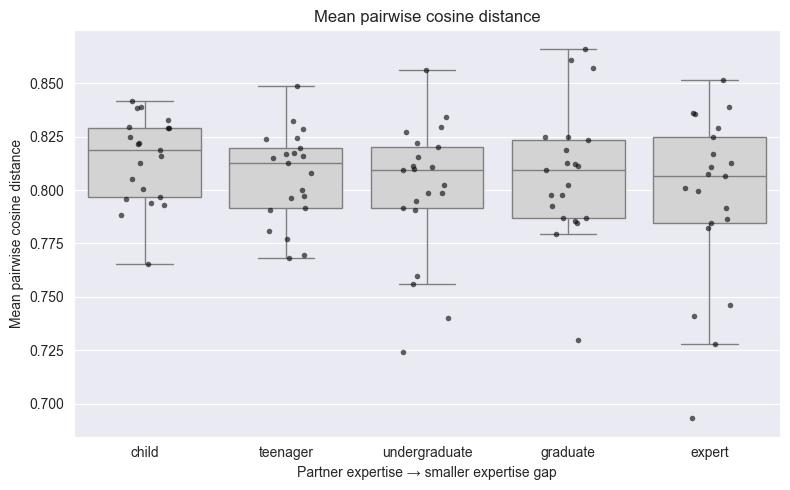

In [233]:
plot_metric_distribution(
    conversation_geometry,
    "pairwise_distance_mean",
    "Mean pairwise cosine distance",
)

In [234]:
conversation_geometry

,dataset,conversation_id,video_id,file_number,level,level_label,n_utterances,n_pairs,n_words,n_turns,...,nearest_neighbor_distance_median,knn_distance_median,maximum_available_rank,numerical_rank,total_variance,spectral_entropy,spectral_entropy_normalized,spectral_effective_rank,participation_ratio,pc1_variance_share
0,wired,wired_Talia_12,talia,12,0,child,27,351,315,14,...,0.501682,0.730119,26,26,0.825017,2.993523,0.918795,19.955860,16.181812,0.133915
1,wired,wired_astro_12,astro,12,0,child,56,1540,647,23,...,0.399942,0.595853,55,55,0.816119,3.508485,0.875516,33.397620,22.543430,0.121501
2,wired,wired_blockchain_12,blockchain,12,0,child,20,190,191,9,...,0.433820,0.788989,19,19,0.832669,2.693383,0.914736,14.781598,12.488393,0.148911
3,wired,wired_crispr_12,crispr,12,0,child,21,210,152,12,...,0.403874,0.757450,20,18,0.812852,2.639855,0.881205,14.011167,11.503853,0.174152
4,wired,wired_dimension_12,dimension,12,0,child,89,3916,689,50,...,0.310556,0.546307,88,81,0.795924,3.683957,0.822801,39.803570,22.846723,0.144173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,wired,wired_nuclear_16,nuclear,16,4,expert,44,946,849,11,...,0.445602,0.629145,43,43,0.791545,3.391523,0.901713,29.711171,21.622796,0.128743
101,wired,wired_sensing_16,sensing,16,4,expert,56,1540,882,27,...,0.486627,0.652179,55,50,0.829185,3.464621,0.864570,31.964335,21.181875,0.141975
102,wired,wired_sleep_16,sleep,16,4,expert,31,465,823,13,...,0.341957,0.446537,30,30,0.693088,2.986731,0.878141,19.820781,13.797187,0.177302
103,wired,wired_time_16,time,16,4,expert,63,1953,1182,23,...,0.483401,0.622610,62,62,0.801034,3.757115,0.910345,42.824685,31.911495,0.083664


In [235]:
def plot_metric_trajectories(df, metric, ylabel=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    # One thin trajectory per topic
    sns.lineplot(
        data=df,
        x="level",
        y=metric,
        units="video_id",
        estimator=None,
        color="gray",
        alpha=0.3,
        linewidth=1,
        marker="o",
        markersize=3,
        ax=ax,
    )

    # Overall mean and 95% bootstrap CI
    sns.lineplot(
        data=df,
        x="level",
        y=metric,
        estimator="mean",
        errorbar=("ci", 95),
        color="black",
        linewidth=3,
        marker="o",
        markersize=7,
        ax=ax,
    )

    ax.set_xticks(range(5))
    ax.set_xticklabels(level_order)
    ax.set_xlabel("Partner expertise → smaller expertise gap")
    ax.set_ylabel(ylabel or metric)
    ax.set_title(ylabel or metric)

    plt.tight_layout()
    plt.show()

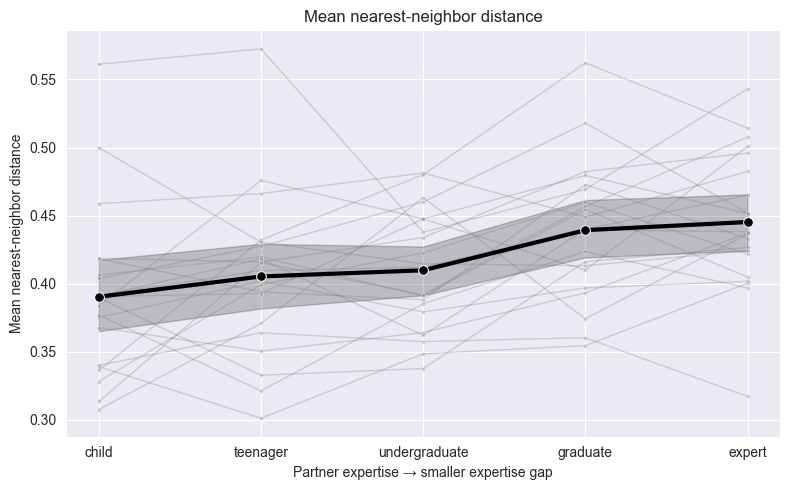

In [236]:
plot_metric_trajectories(
    conversation_geometry,
    "nearest_neighbor_distance_mean",
    "Mean nearest-neighbor distance",
)

In [237]:
def plot_child_expert_difference(df, metric, ylabel=None):
    endpoints = (
        df[df["level_label"].isin(["child", "expert"])]
        .pivot(
            index="video_id",
            columns="level_label",
            values=metric,
        )
        .dropna()
    )

    endpoints["difference"] = (
        endpoints["expert"] - endpoints["child"]
    )

    endpoints = endpoints.sort_values("difference")

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(
        endpoints["difference"],
        endpoints.index,
        color="black",
        s=35,
    )

    ax.axvline(0, color="gray", linestyle="--")

    ax.axvline(
        endpoints["difference"].mean(),
        color="red",
        linewidth=2,
        label=(
            "Mean difference = "
            f"{endpoints['difference'].mean():.3f}"
        ),
    )

    ax.set_xlabel(
        f"Expert − child difference\n"
        f"({ylabel or metric})"
    )
    ax.set_ylabel("Topic")
    ax.set_title("Smallest gap versus largest gap")
    ax.legend()

    plt.tight_layout()
    plt.show()

In [238]:
def plot_sample_size_diagnostic(df, metric, ylabel=None):
    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=df,
        x="n_utterances",
        y=metric,
        hue="level_label",
        hue_order=level_order,
        alpha=0.8,
    )

    sns.regplot(
        data=df,
        x="n_utterances",
        y=metric,
        scatter=False,
        color="black",
        line_kws={"linestyle": "--"},
    )

    plt.xlabel("Number of utterances")
    plt.ylabel(ylabel or metric)
    plt.title(f"{ylabel or metric} versus conversation size")
    plt.tight_layout()
    plt.show()

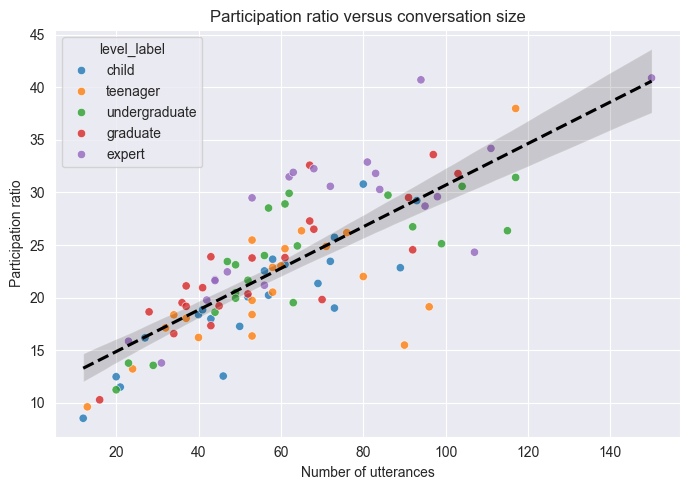

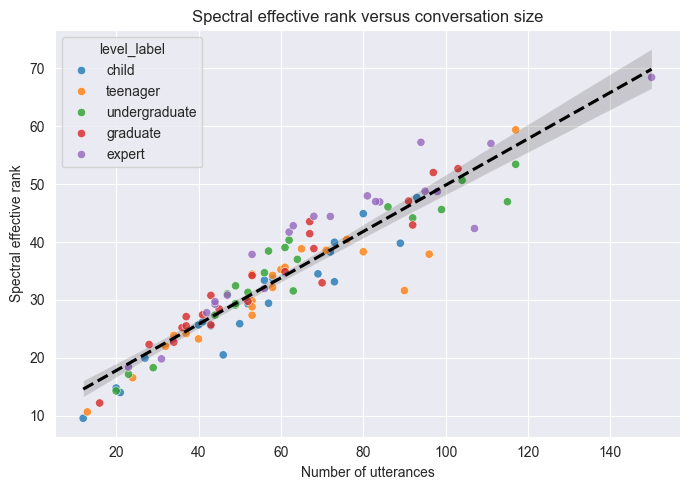

In [239]:
plot_sample_size_diagnostic(
    conversation_geometry,
    "participation_ratio",
    "Participation ratio",
)

plot_sample_size_diagnostic(
    conversation_geometry,
    "spectral_effective_rank",
    "Spectral effective rank",
)

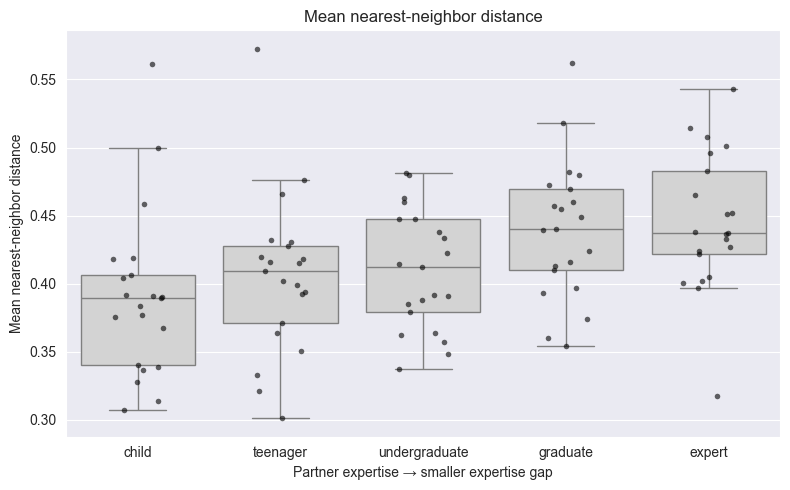

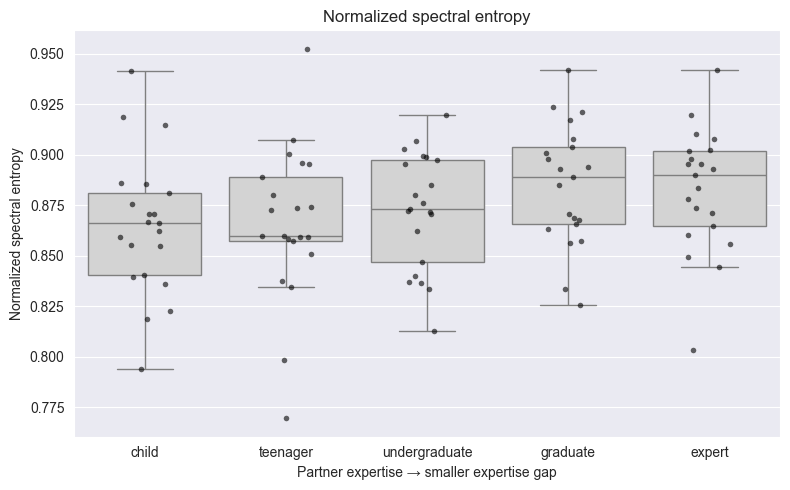

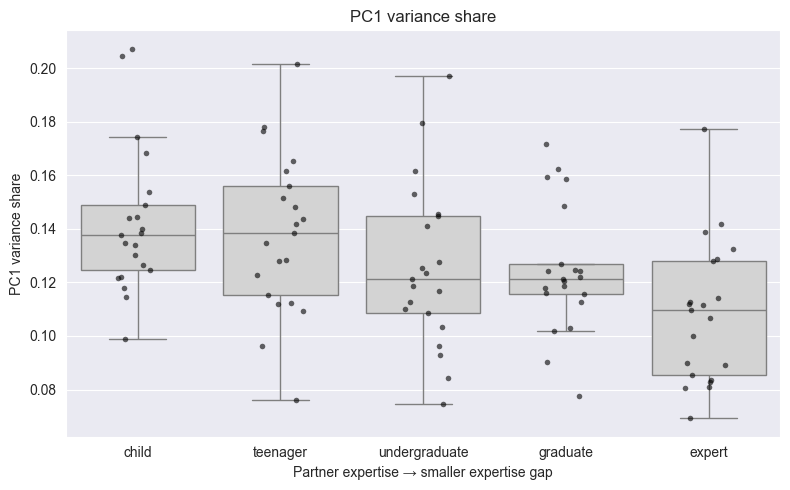

In [240]:
plot_metric_distribution(
    conversation_geometry,
    "nearest_neighbor_distance_mean",
    "Mean nearest-neighbor distance",
)

plot_metric_distribution(
    conversation_geometry,
    "spectral_entropy_normalized",
    "Normalized spectral entropy",
)

plot_metric_distribution(
    conversation_geometry,
    "pc1_variance_share",
    "PC1 variance share",
)

# dynamic metrics

In [241]:
import re
import numpy as np
import pandas as pd


def _sample_sd(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) < 2:
        return np.nan

    return float(np.std(values, ddof=1))


def _linear_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 2:
        return np.nan

    x = x[valid]
    y = y[valid]

    if np.isclose(np.ptp(x), 0):
        return np.nan

    return float(np.polyfit(x, y, deg=1)[0])


def _mean_or_nan(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    return float(np.mean(values))


def standardize_speaker_role(value):
    """
    Convert existing speaker labels to 'expert' or 'learner'.

    This recognizes labels such as:
        Speaker A
        Speaker B
        Speaker 1
        expert
        child
        teenager
        college student
        graduate student
    """
    if pd.isna(value):
        return None

    label = str(value).strip().lower()

    if (
        label == "expert"
        or "speaker a" in label
        or re.search(r"\bspeaker\s*1\b", label)
    ):
        return "expert"

    learner_terms = [
        "learner",
        "speaker b",
        "child",
        "teen",
        "student",
        "undergraduate",
        "graduate",
        "college",
        "novice",
        "partner",
    ]

    if any(term in label for term in learner_terms):
        return "learner"

    return None

In [242]:
#trajectory calculations
def _calculate_order_metrics(X):
    """
    Calculate metrics that depend directly on utterance order.
    X must already contain unit-normalized embeddings.
    """
    n = len(X)

    # ------------------------------------------------------------
    # Consecutive semantic movement
    # ------------------------------------------------------------

    adjacent_similarities = np.sum(
        X[:-1] * X[1:],
        axis=1,
    )

    adjacent_similarities = np.clip(
        adjacent_similarities,
        -1.0,
        1.0,
    )

    step_cosine_distances = (
        1.0 - adjacent_similarities
    )

    # Euclidean chord distances on the unit sphere.
    # Needed for valid path-efficiency calculations.
    step_chord_distances = np.linalg.norm(
        X[1:] - X[:-1],
        axis=1,
    )

    # Each step is placed at the midpoint between two utterances.
    step_times = (
        np.arange(n - 1) + 0.5
    ) / (n - 1)

    step_distance_slope = _linear_slope(
        step_times,
        step_cosine_distances,
    )

    early_steps = (
        step_cosine_distances[
            step_times <= 1 / 3
        ]
    )

    late_steps = (
        step_cosine_distances[
            step_times >= 2 / 3
        ]
    )

    early_step_mean = _mean_or_nan(early_steps)
    late_step_mean = _mean_or_nan(late_steps)

    # ------------------------------------------------------------
    # Path length, net displacement, and efficiency
    # ------------------------------------------------------------

    total_path_length_chord = float(
        np.sum(step_chord_distances)
    )

    net_displacement_chord = float(
        np.linalg.norm(X[-1] - X[0])
    )

    net_displacement_cosine = float(
        np.clip(
            1.0 - np.dot(X[0], X[-1]),
            0.0,
            2.0,
        )
    )

    if total_path_length_chord > 1e-15:
        trajectory_efficiency_chord = float(
            net_displacement_chord
            / total_path_length_chord
        )
    else:
        trajectory_efficiency_chord = np.nan

    # ------------------------------------------------------------
    # Directional persistence
    # ------------------------------------------------------------

    movement_vectors = X[1:] - X[:-1]

    movement_norms = np.linalg.norm(
        movement_vectors,
        axis=1,
    )

    valid_movements = movement_norms > 1e-15

    movement_directions = np.full_like(
        movement_vectors,
        np.nan,
    )

    movement_directions[valid_movements] = (
        movement_vectors[valid_movements]
        / movement_norms[valid_movements, None]
    )

    persistence_values = []

    for index in range(len(movement_directions) - 1):
        first = movement_directions[index]
        second = movement_directions[index + 1]

        if np.isfinite(first).all() and np.isfinite(second).all():
            persistence_values.append(
                np.clip(
                    np.dot(first, second),
                    -1.0,
                    1.0,
                )
            )

    persistence_values = np.asarray(
        persistence_values,
        dtype=float,
    )

    directional_persistence_mean = _mean_or_nan(
        persistence_values
    )

    if len(persistence_values):
        directional_reversal_rate = float(
            np.mean(persistence_values < 0)
        )
    else:
        directional_reversal_rate = np.nan

    # ------------------------------------------------------------
    # Change in movement magnitude
    # ------------------------------------------------------------

    step_size_changes = np.diff(
        step_cosine_distances
    )

    mean_absolute_step_change = _mean_or_nan(
        np.abs(step_size_changes)
    )

    # ------------------------------------------------------------
    # Distance from the beginning
    # ------------------------------------------------------------

    utterance_times = np.linspace(0, 1, n)

    distance_from_start = np.clip(
        1.0 - X @ X[0],
        0.0,
        2.0,
    )

    distance_from_start_slope = _linear_slope(
        utterance_times,
        distance_from_start,
    )

    distance_from_start_auc = float(
        np.trapz(
            distance_from_start,
            utterance_times,
        )
    )

    maximum_index = int(
        np.argmax(distance_from_start)
    )

    return {
        "step_cosine_distances":
            step_cosine_distances,

        "step_chord_distances":
            step_chord_distances,

        "step_times":
            step_times,

        "step_distance_slope":
            step_distance_slope,

        "step_distance_early_mean":
            early_step_mean,

        "step_distance_late_mean":
            late_step_mean,

        "step_distance_late_minus_early":
            late_step_mean - early_step_mean,

        "total_path_length_chord":
            total_path_length_chord,

        "net_displacement_chord":
            net_displacement_chord,

        "net_displacement_cosine":
            net_displacement_cosine,

        "trajectory_efficiency_chord":
            trajectory_efficiency_chord,

        "directional_persistence_values":
            persistence_values,

        "directional_persistence_mean":
            directional_persistence_mean,

        "directional_reversal_rate":
            directional_reversal_rate,

        "step_size_changes":
            step_size_changes,

        "mean_absolute_step_change":
            mean_absolute_step_change,

        "utterance_times":
            utterance_times,

        "distance_from_start":
            distance_from_start,

        "distance_from_start_slope":
            distance_from_start_slope,

        "distance_from_start_auc":
            distance_from_start_auc,

        "distance_from_start_max":
            float(distance_from_start[maximum_index]),

        "distance_from_start_max_time":
            float(utterance_times[maximum_index]),
    }

In [243]:
#conversation-level dynamic function
#adds comparison against all pair geometry, recurrence, speaker transitions, and shuffle-order baselines
def calculate_conversation_dynamics(
    embeddings,
    speaker_roles=None,
    recurrence_min_lag=4,
    recurrence_max_lag=10,
    n_permutations=200,
    random_state=2026,
):
    """
    Calculate Stage 1 trajectory metrics for one conversation.

    Parameters
    ----------
    embeddings : array, shape (n_utterances, embedding_dimension)
        Embeddings in chronological order.

    speaker_roles : array-like, optional
        One standardized speaker role per utterance:
        'expert' or 'learner'.

    recurrence_min_lag : int
        Smallest utterance separation treated as nonlocal.

    recurrence_max_lag : int
        Largest separation used for medium-lag recurrence.

    n_permutations : int
        Number of fixed-endpoint shuffled-order baselines.

    random_state : int
        Reproducibility seed.

    Returns
    -------
    scalar_metrics : dict
        One-row-per-conversation summaries.

    dynamic_series : dict
        Arrays retained for later trajectory plots.
    """
    X = np.asarray(
        embeddings,
        dtype=np.float64,
    )

    if X.ndim != 2:
        raise ValueError(
            "embeddings must have shape "
            "(n_utterances, embedding_dimension)"
        )

    if len(X) < 4:
        raise ValueError(
            "At least four utterances are required "
            "for Stage 1 dynamics."
        )

    if not np.isfinite(X).all():
        raise ValueError(
            "Embeddings contain NaN or infinite values."
        )

    norms = np.linalg.norm(
        X,
        axis=1,
        keepdims=True,
    )

    if np.any(norms == 0):
        raise ValueError(
            "At least one embedding has zero norm."
        )

    X = X / norms

    n, d = X.shape

    ordered = _calculate_order_metrics(X)

    # ------------------------------------------------------------
    # 1. Static all-pair baseline
    # ------------------------------------------------------------

    similarity_matrix = np.clip(
        X @ X.T,
        -1.0,
        1.0,
    )

    upper_triangle = np.triu_indices(
        n,
        k=1,
    )

    all_pair_similarities = (
        similarity_matrix[upper_triangle]
    )

    all_pair_distances = (
        1.0 - all_pair_similarities
    )

    all_pair_distance_mean = float(
        np.mean(all_pair_distances)
    )

    all_pair_similarity_mean = float(
        np.mean(all_pair_similarities)
    )

    step_distance_mean = float(
        np.mean(
            ordered["step_cosine_distances"]
        )
    )

    # Negative = adjacent utterances are closer than arbitrary pairs.
    step_distance_excess = float(
        step_distance_mean
        - all_pair_distance_mean
    )

    # ------------------------------------------------------------
    # 2. Medium-lag recurrence
    # ------------------------------------------------------------

    largest_lag = min(
        recurrence_max_lag,
        n - 1,
    )

    recurrence_by_lag = {}

    if largest_lag >= recurrence_min_lag:
        for lag in range(
            recurrence_min_lag,
            largest_lag + 1,
        ):
            lag_similarities = np.sum(
                X[:-lag] * X[lag:],
                axis=1,
            )

            recurrence_by_lag[lag] = float(
                np.mean(
                    np.clip(
                        lag_similarities,
                        -1.0,
                        1.0,
                    )
                )
            )

        # Each lag receives equal weight.
        medium_lag_similarity_mean = float(
            np.mean(
                list(recurrence_by_lag.values())
            )
        )

        medium_lag_excess_similarity = float(
            medium_lag_similarity_mean
            - all_pair_similarity_mean
        )

    else:
        medium_lag_similarity_mean = np.nan
        medium_lag_excess_similarity = np.nan

    # Exploratory: closest eligible prior utterance.
    # This is more sensitive to conversation length.
    best_prior_similarities = []
    best_prior_lags = []

    for current_index in range(
        recurrence_min_lag,
        n,
    ):
        last_eligible_index = (
            current_index
            - recurrence_min_lag
        )

        prior_similarities = (
            X[:last_eligible_index + 1]
            @ X[current_index]
        )

        best_index = int(
            np.argmax(prior_similarities)
        )

        best_prior_similarities.append(
            prior_similarities[best_index]
        )

        best_prior_lags.append(
            current_index - best_index
        )

    # ------------------------------------------------------------
    # 3. Speaker-transition movement
    # ------------------------------------------------------------

    transition_results = {
        "speaker_switch_rate": np.nan,

        "expert_to_learner_step_mean": np.nan,
        "learner_to_expert_step_mean": np.nan,
        "expert_to_expert_step_mean": np.nan,
        "learner_to_learner_step_mean": np.nan,

        "n_expert_to_learner_steps": 0,
        "n_learner_to_expert_steps": 0,
        "n_expert_to_expert_steps": 0,
        "n_learner_to_learner_steps": 0,

        "learner_to_expert_minus_expert_to_learner_step":
            np.nan,
    }

    if speaker_roles is not None:
        roles = np.asarray(
            speaker_roles,
            dtype=object,
        )

        if len(roles) != n:
            raise ValueError(
                "speaker_roles must have one value "
                "per utterance."
            )

        transition_values = {
            "expert_to_learner": [],
            "learner_to_expert": [],
            "expert_to_expert": [],
            "learner_to_learner": [],
        }

        known_transitions = 0
        speaker_switches = 0

        for index, distance in enumerate(
            ordered["step_cosine_distances"]
        ):
            source = roles[index]
            target = roles[index + 1]

            if (
                source not in {"expert", "learner"}
                or target not in {"expert", "learner"}
            ):
                continue

            known_transitions += 1

            if source != target:
                speaker_switches += 1

            transition_name = (
                f"{source}_to_{target}"
            )

            transition_values[
                transition_name
            ].append(distance)

        if known_transitions:
            transition_results[
                "speaker_switch_rate"
            ] = (
                speaker_switches
                / known_transitions
            )

        for transition_name, values in (
            transition_values.items()
        ):
            transition_results[
                f"{transition_name}_step_mean"
            ] = _mean_or_nan(values)

            transition_results[
                f"n_{transition_name}_steps"
            ] = len(values)

        learner_to_expert = transition_results[
            "learner_to_expert_step_mean"
        ]

        expert_to_learner = transition_results[
            "expert_to_learner_step_mean"
        ]

        if (
            np.isfinite(learner_to_expert)
            and np.isfinite(expert_to_learner)
        ):
            transition_results[
                "learner_to_expert_minus_"
                "expert_to_learner_step"
            ] = (
                learner_to_expert
                - expert_to_learner
            )

    # ------------------------------------------------------------
    # 4. Fixed-endpoint shuffle baselines
    # ------------------------------------------------------------

    shuffle_metric_names = [
        "step_distance_slope",
        "trajectory_efficiency_chord",
        "directional_persistence_mean",
        "distance_from_start_auc",
    ]

    shuffle_values = {
        name: []
        for name in shuffle_metric_names
    }

    rng = np.random.default_rng(
        random_state
    )

    if n_permutations > 0 and n > 3:
        interior_indices = np.arange(
            1,
            n - 1,
        )

        for _ in range(n_permutations):
            shuffled_indices = np.concatenate([
                [0],
                rng.permutation(
                    interior_indices
                ),
                [n - 1],
            ])

            shuffled = _calculate_order_metrics(
                X[shuffled_indices]
            )

            for name in shuffle_metric_names:
                shuffle_values[name].append(
                    shuffled[name]
                )

    shuffle_results = {}

    for name in shuffle_metric_names:
        null_values = np.asarray(
            shuffle_values[name],
            dtype=float,
        )

        null_values = null_values[
            np.isfinite(null_values)
        ]

        observed_value = ordered[name]

        if (
            len(null_values)
            and np.isfinite(observed_value)
        ):
            null_mean = float(
                np.mean(null_values)
            )

            null_sd = (
                float(np.std(null_values, ddof=1))
                if len(null_values) > 1
                else np.nan
            )

            shuffle_results[
                f"{name}_shuffle_mean"
            ] = null_mean

            shuffle_results[
                f"{name}_excess_vs_shuffle"
            ] = (
                observed_value - null_mean
            )

            if (
                np.isfinite(null_sd)
                and null_sd > 1e-15
            ):
                shuffle_results[
                    f"{name}_shuffle_z"
                ] = (
                    observed_value - null_mean
                ) / null_sd
            else:
                shuffle_results[
                    f"{name}_shuffle_z"
                ] = np.nan
        else:
            shuffle_results[
                f"{name}_shuffle_mean"
            ] = np.nan

            shuffle_results[
                f"{name}_excess_vs_shuffle"
            ] = np.nan

            shuffle_results[
                f"{name}_shuffle_z"
            ] = np.nan

    # ------------------------------------------------------------
    # 5. Collect scalar outputs
    # ------------------------------------------------------------

    scalar_metrics = {
        "n_utterances": int(n),
        "n_steps": int(n - 1),
        "embedding_dimension": int(d),

        # Consecutive movement
        "step_cosine_distance_mean":
            step_distance_mean,

        "step_cosine_distance_sd":
            _sample_sd(
                ordered["step_cosine_distances"]
            ),

        "step_cosine_distance_median":
            float(
                np.median(
                    ordered[
                        "step_cosine_distances"
                    ]
                )
            ),

        "step_cosine_distance_q90":
            float(
                np.quantile(
                    ordered[
                        "step_cosine_distances"
                    ],
                    0.90,
                )
            ),

        # Dynamic movement relative to global geometry
        "all_pair_distance_mean_check":
            all_pair_distance_mean,

        "step_distance_excess_over_all_pairs":
            step_distance_excess,

        # Development over time
        "step_distance_slope":
            ordered["step_distance_slope"],

        "step_distance_early_mean":
            ordered["step_distance_early_mean"],

        "step_distance_late_mean":
            ordered["step_distance_late_mean"],

        "step_distance_late_minus_early":
            ordered[
                "step_distance_late_minus_early"
            ],

        # Path structure
        "total_path_length_chord":
            ordered["total_path_length_chord"],

        "net_displacement_chord":
            ordered["net_displacement_chord"],

        "net_displacement_cosine":
            ordered["net_displacement_cosine"],

        "trajectory_efficiency_chord":
            ordered[
                "trajectory_efficiency_chord"
            ],

        # Direction and volatility
        "directional_persistence_mean":
            ordered[
                "directional_persistence_mean"
            ],

        "directional_reversal_rate":
            ordered[
                "directional_reversal_rate"
            ],

        "mean_absolute_step_change":
            ordered[
                "mean_absolute_step_change"
            ],

        # Recurrence
        "medium_lag_similarity_mean":
            medium_lag_similarity_mean,

        "medium_lag_excess_similarity":
            medium_lag_excess_similarity,

        "best_prior_recurrence_similarity_mean":
            _mean_or_nan(
                best_prior_similarities
            ),

        "best_prior_recurrence_lag_mean":
            _mean_or_nan(
                best_prior_lags
            ),

        # Development away from the beginning
        "distance_from_start_slope":
            ordered[
                "distance_from_start_slope"
            ],

        "distance_from_start_auc":
            ordered[
                "distance_from_start_auc"
            ],

        "distance_from_start_max":
            ordered[
                "distance_from_start_max"
            ],

        "distance_from_start_max_time":
            ordered[
                "distance_from_start_max_time"
            ],

        # Null-model bookkeeping
        "n_order_permutations":
            int(n_permutations),
    }

    scalar_metrics.update(
        transition_results
    )

    scalar_metrics.update(
        shuffle_results
    )

    dynamic_series = {
        "step_times":
            ordered["step_times"],

        "step_cosine_distances":
            ordered["step_cosine_distances"],

        "step_chord_distances":
            ordered["step_chord_distances"],

        "directional_persistence":
            ordered[
                "directional_persistence_values"
            ],

        "utterance_times":
            ordered["utterance_times"],

        "distance_from_start":
            ordered["distance_from_start"],

        "recurrence_by_lag":
            recurrence_by_lag,
    }

    # Mathematical check for chord-distance efficiency.
    if np.isfinite(
        scalar_metrics[
            "trajectory_efficiency_chord"
        ]
    ):
        assert (
            -1e-10
            <= scalar_metrics[
                "trajectory_efficiency_chord"
            ]
            <= 1 + 1e-10
        )

    return scalar_metrics, dynamic_series

apply calculations to each conversation

In [244]:
# Find the speaker column used in the existing table.
speaker_candidates = [
    "speaker_role",
    "speaker",
    "speaker_label",
]

speaker_column = next(
    (
        column
        for column in speaker_candidates
        if column in geometry_utterances.columns
    ),
    None,
)

print("Speaker column:", speaker_column)

if speaker_column is None:
    print(
        "No recognized speaker column found. "
        "General dynamics will still be calculated, "
        "but speaker-transition metrics will be missing."
    )

Speaker column: speaker_role


In [245]:
dynamic_records = []
conversation_dynamic_series = {}

group_columns = [
    "dataset",
    "conversation_id",
]

for group_number, (group_key, group) in enumerate(
    geometry_utterances.groupby(
        group_columns,
        sort=False,
        observed=True,
    )
):
    dataset, conversation_id = group_key

    # embedding_idx follows the original transcript order.
    group = (
        group
        .sort_values(
            "embedding_idx",
            kind="stable",
        )
        .copy()
    )

    embedding_indices = group[
        "embedding_idx"
    ].to_numpy(dtype=int)

    conversation_embeddings = (
        E_utterances[embedding_indices]
    )

    if speaker_column is not None:
        speaker_roles = (
            group[speaker_column]
            .map(standardize_speaker_role)
            .to_numpy()
        )
    else:
        speaker_roles = None

    scalar_metrics, dynamic_series = (
        calculate_conversation_dynamics(
            conversation_embeddings,
            speaker_roles=speaker_roles,

            # Exclude the preceding three utterances.
            recurrence_min_lag=4,

            # Examine returns 4–10 utterances later.
            recurrence_max_lag=10,

            n_permutations=200,

            # Different but reproducible seed per conversation.
            random_state=2026 + group_number,
        )
    )

    row = {
        "dataset": dataset,
        "conversation_id": conversation_id,
    }

    for column in [
        "video_id",
        "file_number",
        "level",
        "level_label",
    ]:
        if column in group.columns:
            row[column] = group[
                column
            ].iloc[0]

    if "n_words" in group.columns:
        row["n_words"] = int(
            group["n_words"].sum()
        )
    elif "text" in group.columns:
        row["n_words"] = int(
            group["text"]
            .astype(str)
            .str.split()
            .str.len()
            .sum()
        )

    if "turn_id" in group.columns:
        row["n_turns"] = int(
            group["turn_id"].nunique()
        )

    row.update(scalar_metrics)
    dynamic_records.append(row)

    conversation_dynamic_series[
        (dataset, conversation_id)
    ] = dynamic_series


conversation_dynamics = pd.DataFrame(
    dynamic_records
)

sort_columns = [
    column
    for column in [
        "level",
        "dataset",
        "conversation_id",
    ]
    if column in conversation_dynamics.columns
]

conversation_dynamics = (
    conversation_dynamics
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

print(
    "Conversations analyzed:",
    len(conversation_dynamics),
)

print(
    "Dynamics table shape:",
    conversation_dynamics.shape,
)

display(conversation_dynamics)

/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_97046/3298689629.py:172: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(


Conversations analyzed: 105
Dynamics table shape: (105, 59)


,dataset,conversation_id,video_id,file_number,level,level_label,n_words,n_turns,n_utterances,n_steps,...,step_distance_slope_shuffle_z,trajectory_efficiency_chord_shuffle_mean,trajectory_efficiency_chord_excess_vs_shuffle,trajectory_efficiency_chord_shuffle_z,directional_persistence_mean_shuffle_mean,directional_persistence_mean_excess_vs_shuffle,directional_persistence_mean_shuffle_z,distance_from_start_auc_shuffle_mean,distance_from_start_auc_excess_vs_shuffle,distance_from_start_auc_shuffle_z
0,wired,wired_Talia_12,talia,12,0,child,315,14,27,26,...,-0.431775,0.041748,0.003638,5.457888,-0.496839,0.043161,1.873163,0.818846,1.110223e-16,NaN
1,wired,wired_astro_12,astro,12,0,child,647,23,56,55,...,-0.025628,0.018487,0.002099,9.623505,-0.493350,0.051439,3.231895,0.883317,-2.220446e-16,NaN
2,wired,wired_blockchain_12,blockchain,12,0,child,191,9,20,19,...,1.299513,0.055104,0.003629,3.356776,-0.494013,0.054655,1.799485,0.888595,1.110223e-16,NaN
3,wired,wired_crispr_12,crispr,12,0,child,152,12,21,20,...,-0.756377,0.052204,0.007296,4.776498,-0.500374,0.042615,1.391224,0.877861,1.110223e-16,NaN
4,wired,wired_dimension_12,dimension,12,0,child,689,50,89,88,...,1.454334,0.011654,0.000793,5.623901,-0.497892,0.055565,4.067861,0.781396,-1.110223e-16,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,wired,wired_nuclear_16,nuclear,16,4,expert,849,11,44,43,...,1.030209,0.024185,0.001414,4.400572,-0.494496,0.002954,0.168527,0.712126,1.110223e-16,NaN
101,wired,wired_sensing_16,sensing,16,4,expert,882,27,56,55,...,0.174412,0.017109,0.000578,2.049066,-0.500762,-0.002061,-0.130711,0.725656,0.000000e+00,NaN
102,wired,wired_sleep_16,sleep,16,4,expert,823,13,31,30,...,-0.456573,0.039395,0.003748,5.401261,-0.490890,-0.021770,-0.888153,0.946041,1.110223e-16,NaN
103,wired,wired_time_16,time,16,4,expert,1182,23,63,62,...,1.406218,0.016999,0.000800,5.354500,-0.498005,0.028564,2.489069,0.729836,3.330669e-16,NaN


In [246]:
if speaker_column is not None:
    speaker_mapping_check = (
        geometry_utterances[
            [speaker_column]
        ]
        .drop_duplicates()
        .assign(
            standardized_role=lambda frame:
                frame[speaker_column].map(
                    standardize_speaker_role
                )
        )
    )

    display(speaker_mapping_check)

,speaker_role,standardized_role
0,partner,learner
1,expert,expert


## visualizations for trajectory metrics

matched topic trajectories for each summary metric

In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

level_order = [
    "child",
    "teenager",
    "undergraduate",
    "graduate",
    "expert",
]

level_x = {
    level: index
    for index, level in enumerate(level_order)
}


def plot_dynamic_metric_trajectories(
    df,
    metric,
    ylabel=None,
    zero_reference=False,
    ax=None,
):
    plot_df = df.dropna(subset=[metric]).copy()

    plot_df["_level_x"] = (
        plot_df["level_label"]
        .astype(str)
        .str.lower()
        .map(level_x)
    )

    plot_df["_video_group"] = (
        plot_df["dataset"].astype(str)
        + "::"
        + plot_df["video_id"].astype(str)
    )

    plot_df = plot_df.dropna(
        subset=["_level_x"]
    )

    if ax is None:
        _, ax = plt.subplots(
            figsize=(8, 5)
        )

    # One matched trajectory per video
    for _, video_df in plot_df.groupby(
        "_video_group"
    ):
        video_df = video_df.sort_values(
            "_level_x"
        )

        ax.plot(
            video_df["_level_x"],
            video_df[metric],
            color="gray",
            alpha=0.25,
            linewidth=1,
            marker="o",
            markersize=3,
        )

    # Mean across videos
    level_means = (
        plot_df.groupby("_level_x")[metric]
        .mean()
        .reindex(range(5))
    )

    ax.plot(
        range(5),
        level_means,
        color="black",
        linewidth=3,
        marker="o",
        markersize=7,
    )

    if zero_reference:
        ax.axhline(
            0,
            color="red",
            linestyle="--",
            linewidth=1,
        )

    ax.set_xticks(range(5))
    ax.set_xticklabels(
        level_order,
        rotation=20,
    )

    ax.set_xlabel(
        "Partner expertise → smaller expertise gap"
    )

    ax.set_ylabel(ylabel or metric)
    ax.set_title(ylabel or metric)

    return ax

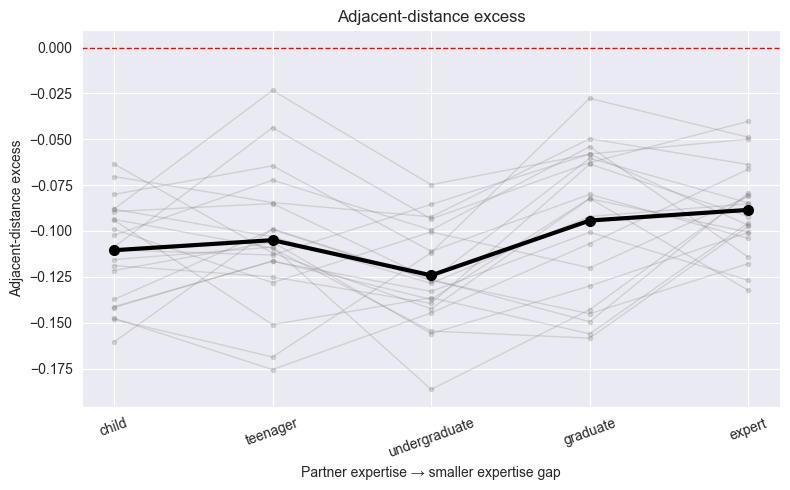

In [248]:
plot_dynamic_metric_trajectories(
    conversation_dynamics,
    metric="step_distance_excess_over_all_pairs",
    ylabel="Adjacent-distance excess",
    zero_reference=True,
)

plt.tight_layout()
plt.show()

In [249]:
dynamic_metric_labels = {
    "step_distance_excess_over_all_pairs":
        "Sequential coherence",

    "step_distance_slope_excess_vs_shuffle":
        "Change in movement over time",

    "trajectory_efficiency_chord_excess_vs_shuffle":
        "Trajectory efficiency vs. shuffle",

    "directional_persistence_mean_excess_vs_shuffle":
        "Directional persistence vs. shuffle",

    "mean_absolute_step_change":
        "Movement volatility",

    "medium_lag_excess_similarity":
        "Medium-lag recurrence",

    "distance_from_start_auc_excess_vs_shuffle":
        "Sustained departure vs. shuffle",

    "learner_to_expert_minus_expert_to_learner_step":
        "Response-transition asymmetry",
}

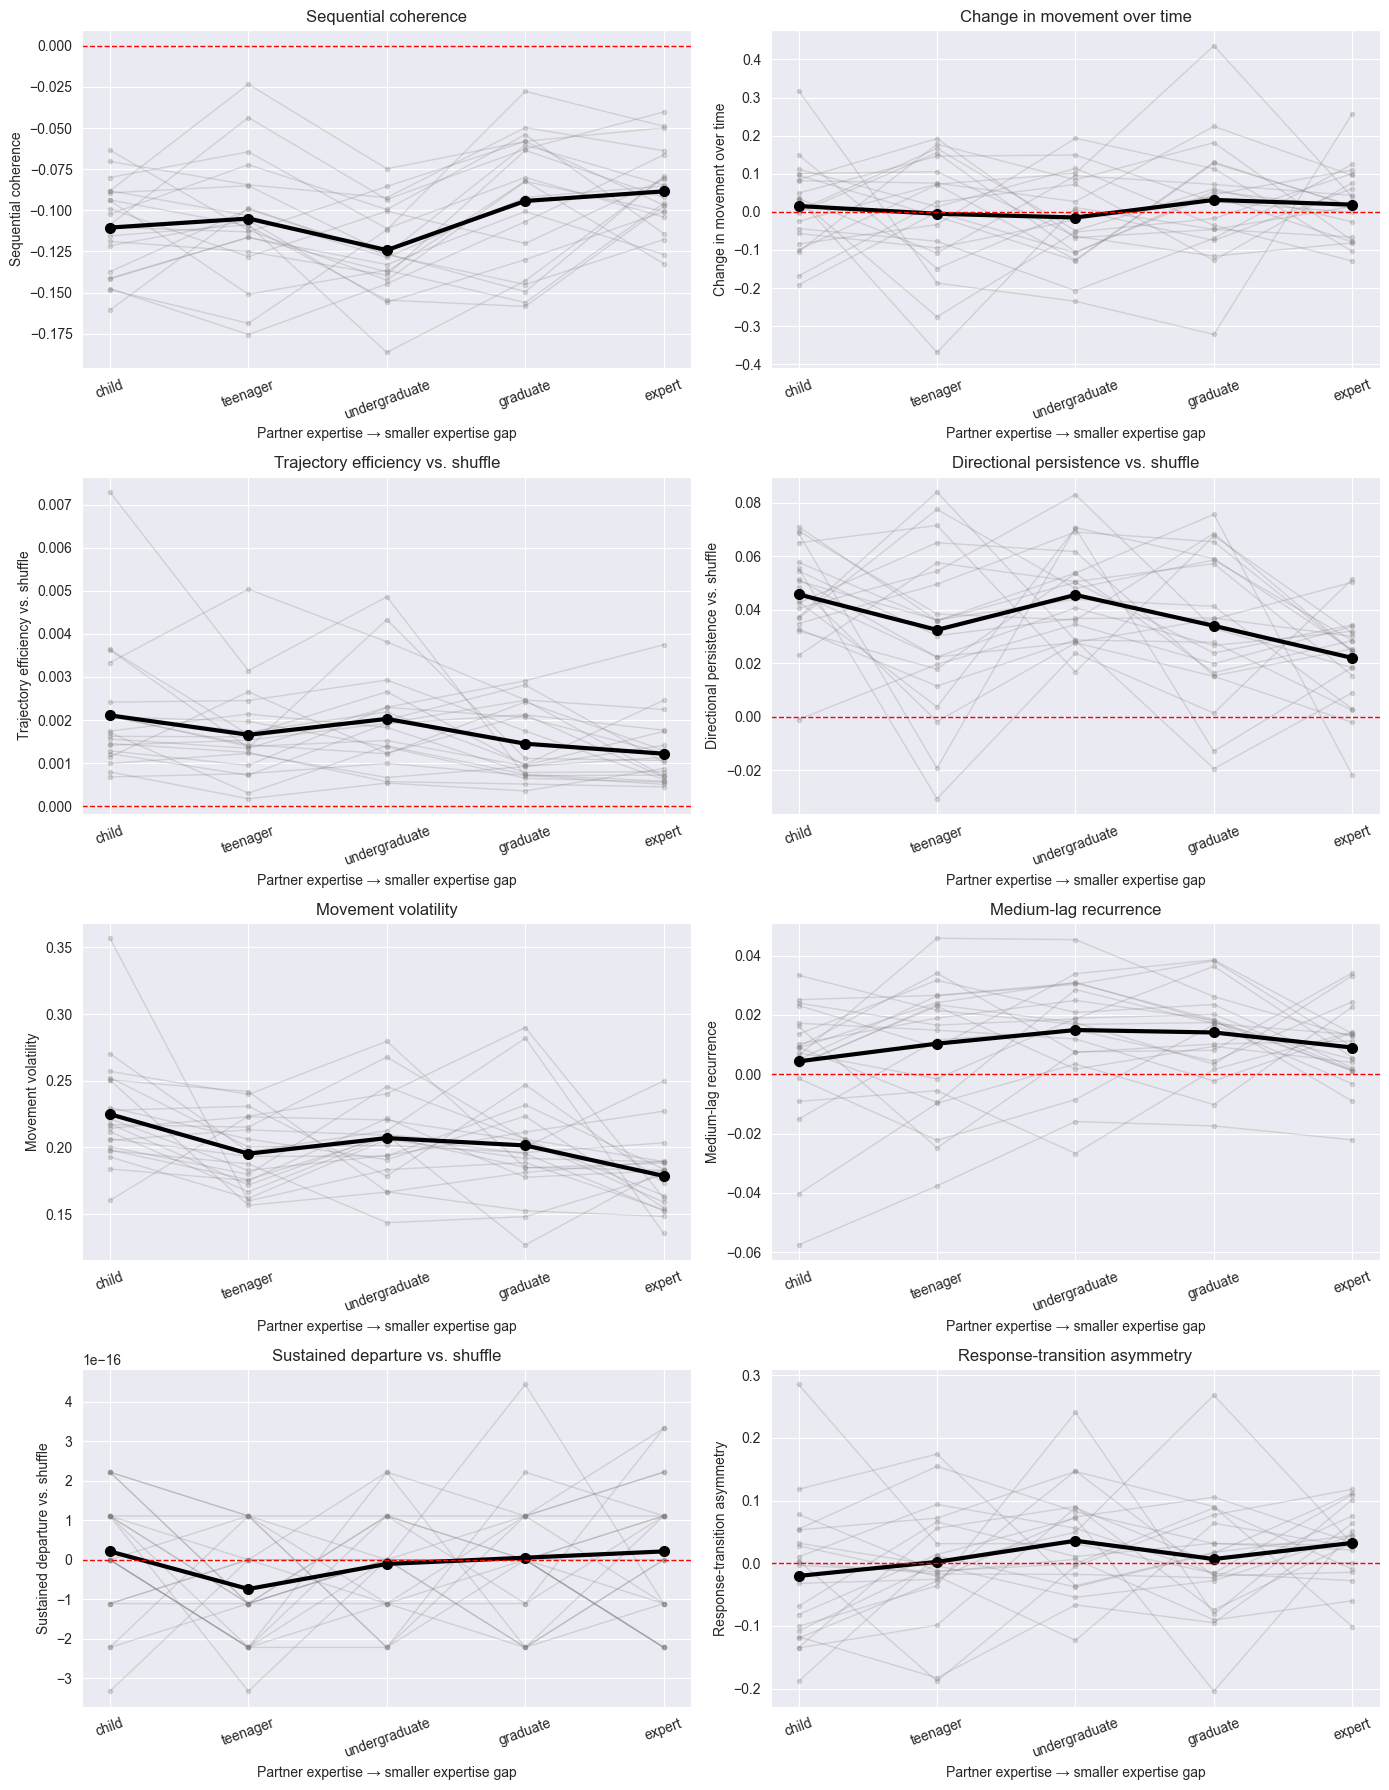

In [250]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 18),
)

axes = axes.flatten()

for ax, (metric, label) in zip(
    axes,
    dynamic_metric_labels.items(),
):
    plot_dynamic_metric_trajectories(
        conversation_dynamics,
        metric=metric,
        ylabel=label,
        zero_reference=(
            "excess" in metric
            or "minus" in metric
        ),
        ax=ax,
    )

plt.tight_layout()
plt.show()

In [251]:
def plot_observed_vs_shuffle(
    df,
    observed_metric,
    shuffle_metric,
    label=None,
):
    plot_df = df.dropna(
        subset=[
            observed_metric,
            shuffle_metric,
        ]
    )

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    sns.scatterplot(
        data=plot_df,
        x=shuffle_metric,
        y=observed_metric,
        hue="level_label",
        hue_order=level_order,
        s=55,
        alpha=0.8,
        ax=ax,
    )

    minimum = min(
        plot_df[observed_metric].min(),
        plot_df[shuffle_metric].min(),
    )

    maximum = max(
        plot_df[observed_metric].max(),
        plot_df[shuffle_metric].max(),
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        color="black",
        linestyle="--",
    )

    ax.set_xlabel("Mean shuffled-order value")
    ax.set_ylabel("Observed-order value")
    ax.set_title(label or observed_metric)

    plt.tight_layout()
    plt.show()

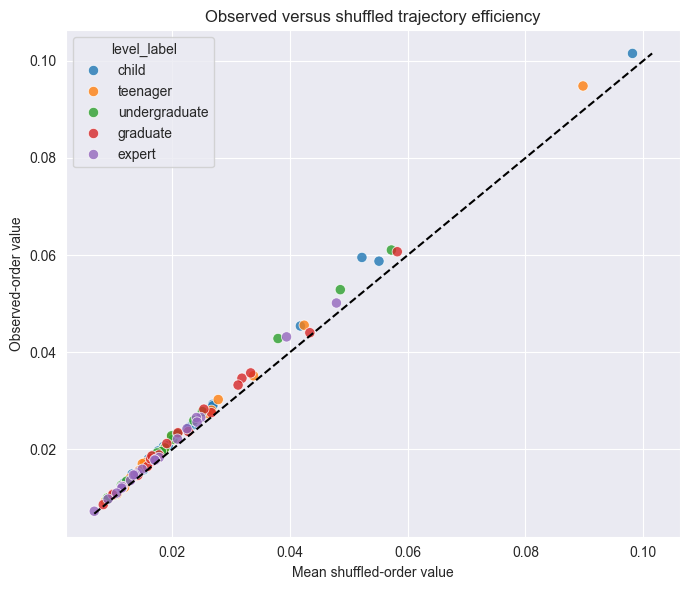

In [252]:
plot_observed_vs_shuffle(
    conversation_dynamics,
    observed_metric=
        "trajectory_efficiency_chord",
    shuffle_metric=
        "trajectory_efficiency_chord_shuffle_mean",
    label="Observed versus shuffled trajectory efficiency",
)

interpretation: above diagonal-> observed convo has higher efficiency than shuffled baseline
colors separating differently around diagonal -> strength of temporal organization vaires with gap

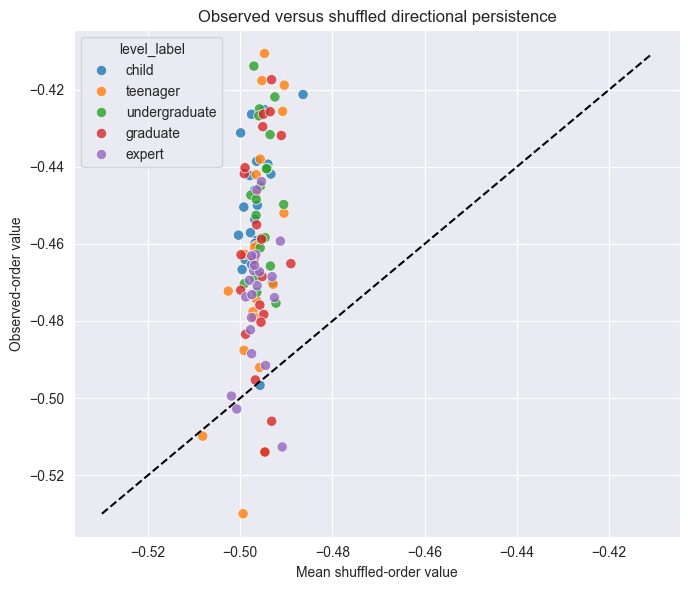

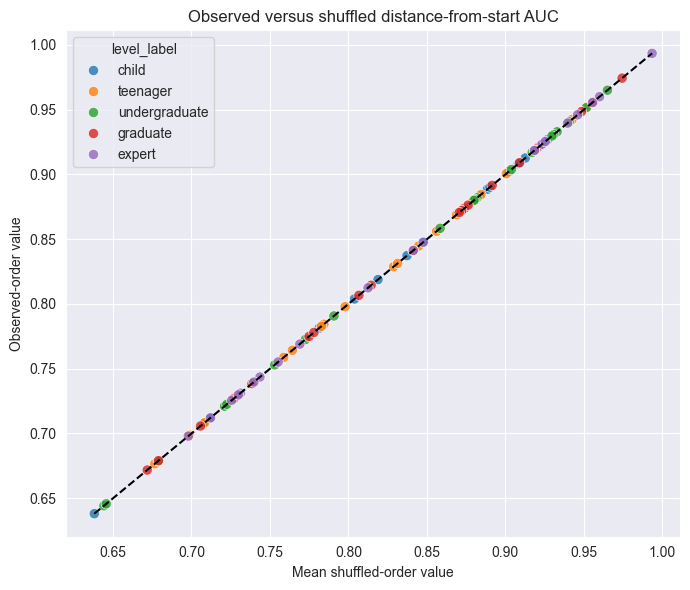

In [253]:
plot_observed_vs_shuffle(
    conversation_dynamics,
    "directional_persistence_mean",
    "directional_persistence_mean_shuffle_mean",
    "Observed versus shuffled directional persistence",
)

plot_observed_vs_shuffle(
    conversation_dynamics,
    "distance_from_start_auc",
    "distance_from_start_auc_shuffle_mean",
    "Observed versus shuffled distance-from-start AUC",
)

### visualizting the actual temporal series

In [254]:
#binned time series table
def build_binned_dynamic_series(
    conversation_dynamics,
    conversation_dynamic_series,
    time_key,
    value_key,
    n_bins=10,
):
    records = []

    for _, row in (
        conversation_dynamics.iterrows()
    ):
        key = (
            row["dataset"],
            row["conversation_id"],
        )

        if key not in conversation_dynamic_series:
            continue

        series = conversation_dynamic_series[key]

        times = np.asarray(
            series[time_key],
            dtype=float,
        )

        values = np.asarray(
            series[value_key],
            dtype=float,
        )

        valid = (
            np.isfinite(times)
            & np.isfinite(values)
        )

        times = times[valid]
        values = values[valid]

        bin_number = np.minimum(
            np.floor(times * n_bins).astype(int),
            n_bins - 1,
        )

        temporary = pd.DataFrame({
            "time_bin": bin_number,
            "value": values,
        })

        # One value per conversation per time bin
        temporary = (
            temporary
            .groupby("time_bin", as_index=False)
            ["value"]
            .mean()
        )

        temporary["normalized_time"] = (
            temporary["time_bin"] + 0.5
        ) / n_bins

        temporary["dataset"] = row["dataset"]
        temporary["conversation_id"] = (
            row["conversation_id"]
        )
        temporary["video_id"] = row["video_id"]
        temporary["level_label"] = (
            str(row["level_label"]).lower()
        )

        records.append(temporary)

    return pd.concat(
        records,
        ignore_index=True,
    )

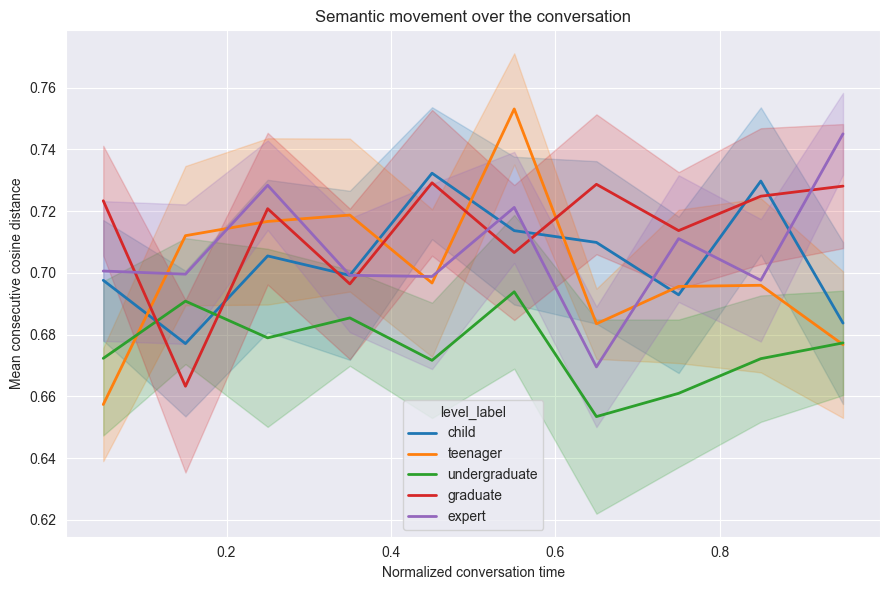

In [255]:
#plot sematic movement over tim e
step_time_df = build_binned_dynamic_series(
    conversation_dynamics,
    conversation_dynamic_series,
    time_key="step_times",
    value_key="step_cosine_distances",
    n_bins=10,
)

plt.figure(figsize=(9, 6))

sns.lineplot(
    data=step_time_df,
    x="normalized_time",
    y="value",
    hue="level_label",
    hue_order=level_order,
    estimator="mean",
    errorbar=("se", 1),
    linewidth=2,
)

plt.xlabel("Normalized conversation time")
plt.ylabel("Mean consecutive cosine distance")
plt.title("Semantic movement over the conversation")
plt.tight_layout()
plt.show()

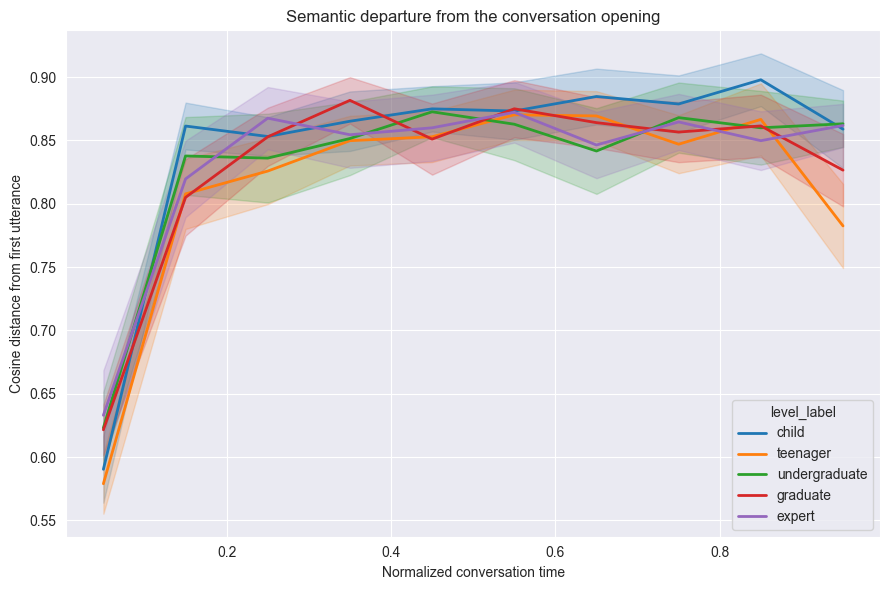

In [256]:
#distance from beginning
start_distance_df = (
    build_binned_dynamic_series(
        conversation_dynamics,
        conversation_dynamic_series,
        time_key="utterance_times",
        value_key="distance_from_start",
        n_bins=10,
    )
)

plt.figure(figsize=(9, 6))

sns.lineplot(
    data=start_distance_df,
    x="normalized_time",
    y="value",
    hue="level_label",
    hue_order=level_order,
    estimator="mean",
    errorbar=("se", 1),
    linewidth=2,
)

plt.xlabel("Normalized conversation time")
plt.ylabel("Cosine distance from first utterance")
plt.title("Semantic departure from the conversation opening")
plt.tight_layout()
plt.show()

In [257]:
#when conversation RETURN to related semantic material
recurrence_records = []

for _, row in conversation_dynamics.iterrows():
    key = (
        row["dataset"],
        row["conversation_id"],
    )

    recurrence_by_lag = (
        conversation_dynamic_series[key]
        ["recurrence_by_lag"]
    )

    for lag, similarity in (
        recurrence_by_lag.items()
    ):
        recurrence_records.append({
            "dataset": row["dataset"],
            "conversation_id":
                row["conversation_id"],
            "video_id": row["video_id"],
            "level_label":
                str(row["level_label"]).lower(),
            "lag": lag,
            "similarity": similarity,
        })

recurrence_lag_df = pd.DataFrame(
    recurrence_records
)

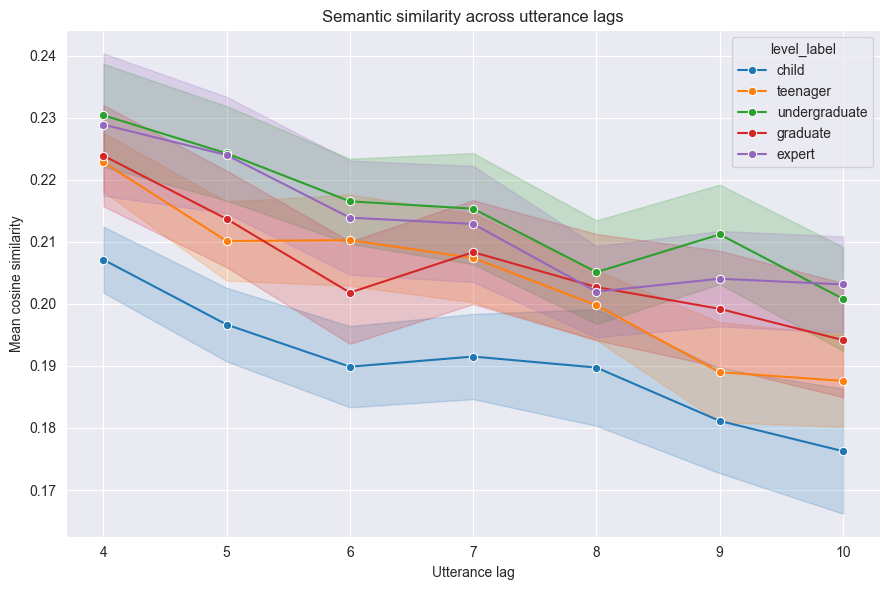

In [258]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=recurrence_lag_df,
    x="lag",
    y="similarity",
    hue="level_label",
    hue_order=level_order,
    estimator="mean",
    errorbar=("se", 1),
    marker="o",
)

plt.xlabel("Utterance lag")
plt.ylabel("Mean cosine similarity")
plt.title("Semantic similarity across utterance lags")
plt.tight_layout()
plt.show()

interpretation: slow decline -> semantic material remains active over longer spans
lower curve -> faster semantic departure

In [259]:
#speaker transition plot
transition_long = conversation_dynamics.melt(
    id_vars=[
        "dataset",
        "video_id",
        "conversation_id",
        "level_label",
    ],
    value_vars=[
        "expert_to_learner_step_mean",
        "learner_to_expert_step_mean",
    ],
    var_name="transition",
    value_name="mean_step_distance",
)

transition_long["transition"] = (
    transition_long["transition"].map({
        "expert_to_learner_step_mean":
            "Expert → learner",

        "learner_to_expert_step_mean":
            "Learner → expert",
    })
)

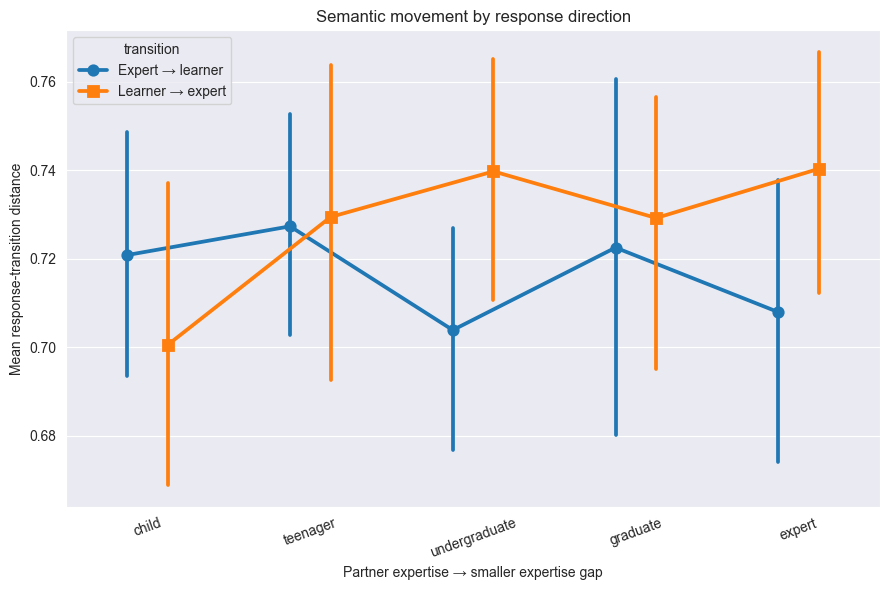

In [260]:
plt.figure(figsize=(9, 6))

sns.pointplot(
    data=transition_long,
    x="level_label",
    y="mean_step_distance",
    hue="transition",
    order=level_order,
    errorbar=("ci", 95),
    dodge=0.25,
    markers=["o", "s"],
)

plt.xlabel(
    "Partner expertise → smaller expertise gap"
)
plt.ylabel("Mean response-transition distance")
plt.title("Semantic movement by response direction")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

interpretation: learner to expert higher -> expert response introduce more semantic movement. if lines converge as expertise increases, it would suggest that response direction asymmetry shrinks with gap. diverging lines would suggest more asymmetry

## change focus to time windows

previous part looks at OVERALL CONVERSATION'S TRAJECTORY. now look at HOW local geometry changes from beginning to end

divide each convo into 5 windows, each containing 20% of the conversation.(important to note that this can cause issues since utterance count/amount of text within each window will differ)

In [261]:
import numpy as np
import pandas as pd

n_windows = 5

window_count_records = []

for group_key, group in geometry_utterances.groupby(
    ["dataset", "conversation_id"],
    sort=False,
    observed=True,
):
    dataset, conversation_id = group_key

    group = (
        group
        .sort_values(
            "embedding_idx",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    window_positions = np.array_split(
        np.arange(len(group)),
        n_windows,
    )

    for window_index, positions in enumerate(
        window_positions,
        start=1,
    ):
        row = {
            "dataset": dataset,
            "conversation_id": conversation_id,
            "window_index": window_index,
            "n_window_utterances": len(positions),
        }

        for column in [
            "video_id",
            "level",
            "level_label",
        ]:
            if column in group.columns:
                row[column] = group[column].iloc[0]

        window_count_records.append(row)


window_counts = pd.DataFrame(
    window_count_records
)

display(
    window_counts[
        "n_window_utterances"
    ].describe()
)

display(
    window_counts.sort_values(
        "n_window_utterances"
    ).head(20)
)

count    525.000000
mean      12.160000
std        5.302052
min        2.000000
25%        9.000000
50%       11.000000
75%       15.000000
max       30.000000
Name: n_window_utterances, dtype: float64

,dataset,conversation_id,window_index,n_window_utterances,video_id,level,level_label
384,wired,wired_neuro_13,5,2,neuro,1,teenager
379,wired,wired_neuro_12,5,2,neuro,0,child
378,wired,wired_neuro_12,4,2,neuro,0,child
383,wired,wired_neuro_13,4,2,neuro,1,teenager
377,wired,wired_neuro_12,3,2,neuro,0,child
375,wired,wired_neuro_12,1,3,neuro,0,child
393,wired,wired_neuro_15,4,3,neuro,3,graduate
392,wired,wired_neuro_15,3,3,neuro,3,graduate
380,wired,wired_neuro_13,1,3,neuro,1,teenager
394,wired,wired_neuro_15,5,3,neuro,3,graduate


In [262]:
print("Number of windows:", len(window_counts))

print(
    window_counts.groupby(
        ["dataset", "conversation_id"]
    ).size().value_counts()
)

Number of windows: 525
5    105
Name: count, dtype: int64


In [263]:
target_m = 20

minimum_window_size = int(
    window_counts[
        "n_window_utterances"
    ].min()
)

m_per_window = min(
    target_m,
    minimum_window_size,
)

print("Smallest window:", minimum_window_size)
print("Utterances sampled per window:", m_per_window)

Smallest window: 2
Utterances sampled per window: 2


In [283]:
candidate_windows = [5, 4, 3]
candidate_m = [8, 10, 12, 15, 20]

design_records = []

for candidate_n_windows in candidate_windows:
    for candidate_sample_size in candidate_m:
        required_utterances = (
            candidate_n_windows
            * candidate_sample_size
        )

        temporary = conversation_sizes.copy()

        temporary["eligible"] = (
            temporary["n_utterances"]
            >= required_utterances
        )

        video_summary = (
            temporary
            .groupby(
                ["dataset", "video_id"],
                observed=True,
            )
            .agg(
                n_levels=(
                    "level_label",
                    "nunique",
                ),
                all_levels_eligible=(
                    "eligible",
                    "all",
                ),
            )
            .reset_index()
        )

        fully_matched_videos = (
            video_summary[
                (
                    video_summary["n_levels"] == 5
                )
                &
                (
                    video_summary[
                        "all_levels_eligible"
                    ]
                )
            ]
        )

        design_records.append({
            "n_windows":
                candidate_n_windows,

            "m_per_window":
                candidate_sample_size,

            "required_utterances":
                required_utterances,

            "eligible_conversations":
                int(
                    temporary[
                        "eligible"
                    ].sum()
                ),

            "eligible_conversations_percent":
                100 * temporary[
                    "eligible"
                ].mean(),

            "fully_matched_videos":
                len(fully_matched_videos),

            "matched_conversations":
                5 * len(
                    fully_matched_videos
                ),
        })


design_comparison = pd.DataFrame(
    design_records
)

display(
    design_comparison.sort_values(
        [
            "n_windows",
            "m_per_window",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

,n_windows,m_per_window,required_utterances,eligible_conversations,eligible_conversations_percent,fully_matched_videos,matched_conversations
0,5,8,40,85,80.952381,10,50
1,5,10,50,67,63.809524,6,30
2,5,12,60,49,46.666667,3,15
3,5,15,75,27,25.714286,1,5
4,5,20,100,8,7.619048,0,0
5,4,8,32,92,87.619048,15,75
6,4,10,40,85,80.952381,10,50
7,4,12,48,70,66.666667,6,30
8,4,15,60,49,46.666667,3,15
9,4,20,80,26,24.761905,1,5


In [265]:
window_metrics = [
    "pairwise_distance_mean",
    "pairwise_distance_sd",
    "radial_distance_q90",
    "nearest_neighbor_distance_mean",
    "knn_distance_median",
    "spectral_entropy_normalized",
    "participation_ratio",
    "pc1_variance_share",
]

In [284]:
n_windows = 3
m_per_window = 10
n_resamples = 200

In [286]:
eligibility_by_level = (
    conversation_sizes
    .groupby(
        "level_label",
        observed=True,
    )
    .agg(
        total_conversations=(
            "conversation_id",
            "count",
        ),
        eligible_conversations=(
            "eligible_stage2",
            "sum",
        ),
    )
)

eligibility_by_level[
    "eligible_percent"
] = (
    100
    * eligibility_by_level[
        "eligible_conversations"
    ]
    / eligibility_by_level[
        "total_conversations"
    ]
)

display(eligibility_by_level)

,total_conversations,eligible_conversations,eligible_percent
level_label,,,
child,21,17,80.952381
teenager,21,19,90.476190
undergraduate,21,18,85.714286
graduate,21,19,90.476190
expert,21,20,95.238095


In [287]:
video_eligibility = (
    conversation_sizes
    .groupby(
        ["dataset", "video_id"],
        observed=True,
    )
    .agg(
        n_levels=(
            "level_label",
            "nunique",
        ),
        all_eligible=(
            "eligible_stage2",
            "all",
        ),
    )
    .reset_index()
)

retained_videos = video_eligibility[
    (
        video_eligibility["n_levels"] == 5
    )
    &
    (
        video_eligibility["all_eligible"]
    )
][
    ["dataset", "video_id"]
].copy()

print(
    "Matched videos retained:",
    len(retained_videos),
)

Matched videos retained: 16


In [288]:
stage2_utterances_matched = (
    geometry_utterances
    .merge(
        retained_videos,
        on=[
            "dataset",
            "video_id",
        ],
        how="inner",
    )
    .copy()
)

print(
    "Matched conversations:",
    stage2_utterances_matched[
        ["dataset", "conversation_id"]
    ].drop_duplicates().shape[0]
)

Matched conversations: 80


In [289]:
eligible_conversation_keys = (
    conversation_sizes[
        conversation_sizes[
            "eligible_stage2"
        ]
    ][
        ["dataset", "conversation_id"]
    ]
)

stage2_utterances_unbalanced = (
    geometry_utterances
    .merge(
        eligible_conversation_keys,
        on=[
            "dataset",
            "conversation_id",
        ],
        how="inner",
    )
    .copy()
)

print(
    "Eligible conversations:",
    stage2_utterances_unbalanced[
        ["dataset", "conversation_id"]
    ].drop_duplicates().shape[0]
)

Eligible conversations: 93


In [291]:
grouped_conversations = (
    stage2_utterances_matched
    .groupby(
        ["dataset", "conversation_id"],
        sort=False,
        observed=True,
    )
)
n_windows = 3
m_per_window = 10
n_resamples = 200

In [292]:
window_geometry_records = []
window_metric_draws = {}

grouped_conversations = (
    stage2_utterances_matched
    .groupby(
        ["dataset", "conversation_id"],
        sort=False,
        observed=True,
    )
)

for group_number, (group_key, group) in enumerate(
    grouped_conversations
):
    dataset, conversation_id = group_key

    # Preserve chronological order
    group = (
        group
        .sort_values(
            "embedding_idx",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    embedding_indices = group[
        "embedding_idx"
    ].to_numpy(dtype=int)

    conversation_embeddings = (
        E_utterances[embedding_indices]
    )

    # Divide into beginning, middle, and end
    window_positions_list = np.array_split(
        np.arange(len(group)),
        n_windows,
    )

    for zero_based_window, window_positions in enumerate(
        window_positions_list
    ):
        window_index = zero_based_window + 1

        assert len(window_positions) >= m_per_window

        # Reproducible independent RNG per window
        seed_sequence = np.random.SeedSequence([
            2026,
            group_number,
            window_index,
        ])

        rng = np.random.default_rng(
            seed_sequence
        )

        # If exactly 10 utterances exist, there is only
        # one possible sample.
        repetitions_used = (
            1
            if len(window_positions) == m_per_window
            else n_resamples
        )

        draw_records = []

        for repetition in range(repetitions_used):
            sampled_positions = rng.choice(
                window_positions,
                size=m_per_window,
                replace=False,
            )

            sampled_embeddings = (
                conversation_embeddings[
                    sampled_positions
                ]
            )

            scalar_metrics, _ = (
                calculate_conversation_geometry(
                    sampled_embeddings,
                    k=5,
                )
            )

            draw_records.append({
                "repetition": repetition,
                **{
                    metric:
                        scalar_metrics[metric]
                    for metric in window_metrics
                },
            })

        draws_df = pd.DataFrame(
            draw_records
        )

        row = {
            "dataset": dataset,
            "conversation_id": conversation_id,
            "window_index": window_index,

            # Actual proportional midpoint:
            # 1/6, 1/2, 5/6
            "window_midpoint": (
                zero_based_window + 0.5
            ) / n_windows,

            # Beginning=0, middle=0.5, end=1
            "time_linear": (
                zero_based_window
                / (n_windows - 1)
            ),

            # Beginning=-0.5, middle=0, end=0.5
            "time_c": (
                zero_based_window
                / (n_windows - 1)
                - 0.5
            ),

            "n_window_utterances":
                len(window_positions),

            "m_sampled":
                m_per_window,

            "n_resamples_used":
                repetitions_used,
        }

        # Retain conversation metadata
        for column in [
            "video_id",
            "file_number",
            "level",
            "level_label",
        ]:
            if column in group.columns:
                row[column] = group[
                    column
                ].iloc[0]

        # Average the repeated subsample estimates
        for metric in window_metrics:
            values = draws_df[
                metric
            ].to_numpy(dtype=float)

            row[metric] = float(
                np.nanmean(values)
            )

            # Monte Carlo/subsampling variability
            row[f"{metric}_mc_sd"] = (
                float(
                    np.nanstd(
                        values,
                        ddof=1,
                    )
                )
                if np.isfinite(values).sum() > 1
                else np.nan
            )

        window_geometry_records.append(row)

        # Retain individual draws for reliability checks
        window_metric_draws[
            (
                dataset,
                conversation_id,
                window_index,
            )
        ] = draws_df

In [293]:
window_geometry = pd.DataFrame(
    window_geometry_records
)

window_geometry = (
    window_geometry
    .sort_values([
        "dataset",
        "conversation_id",
        "window_index",
    ])
    .reset_index(drop=True)
)

display(window_geometry)

,dataset,conversation_id,window_index,window_midpoint,time_linear,time_c,n_window_utterances,m_sampled,n_resamples_used,video_id,...,nearest_neighbor_distance_mean,nearest_neighbor_distance_mean_mc_sd,knn_distance_median,knn_distance_median_mc_sd,spectral_entropy_normalized,spectral_entropy_normalized_mc_sd,participation_ratio,participation_ratio_mc_sd,pc1_variance_share,pc1_variance_share_mc_sd
0,wired,wired_astro_12,1,0.166667,0.0,-0.5,19,10,200,astro,...,0.533801,0.068035,0.846346,0.064842,0.932366,0.021338,6.917569,0.496452,0.242356,0.023375
1,wired,wired_astro_12,2,0.500000,0.5,0.0,19,10,200,astro,...,0.535747,0.057195,0.735528,0.052573,0.944738,0.018306,7.295884,0.429311,0.210868,0.022205
2,wired,wired_astro_12,3,0.833333,1.0,0.5,18,10,200,astro,...,0.476271,0.058176,0.756622,0.116126,0.905318,0.022742,6.171352,0.530456,0.286529,0.033150
3,wired,wired_astro_13,1,0.166667,0.0,-0.5,18,10,200,astro,...,0.458285,0.044909,0.646672,0.068433,0.929994,0.013313,6.835376,0.377221,0.235565,0.027780
4,wired,wired_astro_13,2,0.500000,0.5,0.0,18,10,200,astro,...,0.498202,0.043560,0.754416,0.064602,0.927368,0.010752,6.754261,0.259208,0.242629,0.018410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,wired,wired_zero_15,2,0.500000,0.5,0.0,23,10,200,zero,...,0.452789,0.076006,0.848873,0.060737,0.881161,0.049213,5.993723,0.823146,0.286151,0.050375
236,wired,wired_zero_15,3,0.833333,1.0,0.5,23,10,200,zero,...,0.475508,0.079521,0.820357,0.041657,0.899060,0.051239,6.411248,0.846812,0.271710,0.044308
237,wired,wired_zero_16,1,0.166667,0.0,-0.5,36,10,200,zero,...,0.489811,0.080494,0.821776,0.052438,0.897473,0.052062,6.465853,0.831500,0.257898,0.042814
238,wired,wired_zero_16,2,0.500000,0.5,0.0,36,10,200,zero,...,0.521301,0.080802,0.821359,0.044001,0.918923,0.044573,6.842271,0.811806,0.243931,0.041933


In [295]:
assert window_geometry[
    "pairwise_distance_mean"
].between(0, 2).all()

assert window_geometry[
    "nearest_neighbor_distance_mean"
].between(0, 2).all()

assert window_geometry[
    "spectral_entropy_normalized"
].between(0, 1).all()

assert window_geometry[
    "pc1_variance_share"
].between(0, 1).all()

assert window_geometry[
    "participation_ratio"
].between(1, 9).all()

In [296]:
reliability_records = []

for metric in window_metrics:
    mc_column = f"{metric}_mc_sd"

    reliability_records.append({
        "metric": metric,

        "median_mc_sd":
            window_geometry[
                mc_column
            ].median(),

        "q90_mc_sd":
            window_geometry[
                mc_column
            ].quantile(0.90),

        "maximum_mc_sd":
            window_geometry[
                mc_column
            ].max(),
    })

window_reliability = pd.DataFrame(
    reliability_records
)

display(window_reliability)


,metric,median_mc_sd,q90_mc_sd,maximum_mc_sd
0,pairwise_distance_mean,0.031150,0.045155,0.062051
1,pairwise_distance_sd,0.022216,0.032768,0.060075
2,radial_distance_q90,0.037525,0.056867,0.113312
3,nearest_neighbor_distance_mean,0.056752,0.075938,0.093239
4,knn_distance_median,0.042495,0.075562,0.146597
5,spectral_entropy_normalized,0.017989,0.037920,0.083677
6,participation_ratio,0.463746,0.736092,1.197513
7,pc1_variance_share,0.025570,0.039854,0.077086


In [297]:
window_geometry

,dataset,conversation_id,window_index,window_midpoint,time_linear,time_c,n_window_utterances,m_sampled,n_resamples_used,video_id,...,nearest_neighbor_distance_mean,nearest_neighbor_distance_mean_mc_sd,knn_distance_median,knn_distance_median_mc_sd,spectral_entropy_normalized,spectral_entropy_normalized_mc_sd,participation_ratio,participation_ratio_mc_sd,pc1_variance_share,pc1_variance_share_mc_sd
0,wired,wired_astro_12,1,0.166667,0.0,-0.5,19,10,200,astro,...,0.533801,0.068035,0.846346,0.064842,0.932366,0.021338,6.917569,0.496452,0.242356,0.023375
1,wired,wired_astro_12,2,0.500000,0.5,0.0,19,10,200,astro,...,0.535747,0.057195,0.735528,0.052573,0.944738,0.018306,7.295884,0.429311,0.210868,0.022205
2,wired,wired_astro_12,3,0.833333,1.0,0.5,18,10,200,astro,...,0.476271,0.058176,0.756622,0.116126,0.905318,0.022742,6.171352,0.530456,0.286529,0.033150
3,wired,wired_astro_13,1,0.166667,0.0,-0.5,18,10,200,astro,...,0.458285,0.044909,0.646672,0.068433,0.929994,0.013313,6.835376,0.377221,0.235565,0.027780
4,wired,wired_astro_13,2,0.500000,0.5,0.0,18,10,200,astro,...,0.498202,0.043560,0.754416,0.064602,0.927368,0.010752,6.754261,0.259208,0.242629,0.018410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,wired,wired_zero_15,2,0.500000,0.5,0.0,23,10,200,zero,...,0.452789,0.076006,0.848873,0.060737,0.881161,0.049213,5.993723,0.823146,0.286151,0.050375
236,wired,wired_zero_15,3,0.833333,1.0,0.5,23,10,200,zero,...,0.475508,0.079521,0.820357,0.041657,0.899060,0.051239,6.411248,0.846812,0.271710,0.044308
237,wired,wired_zero_16,1,0.166667,0.0,-0.5,36,10,200,zero,...,0.489811,0.080494,0.821776,0.052438,0.897473,0.052062,6.465853,0.831500,0.257898,0.042814
238,wired,wired_zero_16,2,0.500000,0.5,0.0,36,10,200,zero,...,0.521301,0.080802,0.821359,0.044001,0.918923,0.044573,6.842271,0.811806,0.243931,0.041933


summary: evaluated window design options. since some conversations were just too short, only included videos that fit the design with three sections, ten utterances per window. 16 videos were eligible. the ten utterances in each window were sampled without replacement and the sampling was repeated 200 times(reduces dependence on one arbitrary selection of utterances). resulting estimates were averaged across repetitions, and standard deviation across repetitions was retained as a measure of subsampling variability.window-level metrics were calculated for each (mean and standard deviation of pairwise cosine distance, radial Q90 distance, mean nearest-neighbor distance, median k-nearest-neighbor distance, normalized spectral entropy, participation ratio, and PC1 variance share.)

## visualizing window level stuff

In [298]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

level_order = [
    "child",
    "teenager",
    "undergraduate",
    "graduate",
    "expert",
]

level_palette = dict(
    zip(
        level_order,
        sns.color_palette(
            "viridis",
            len(level_order),
        ),
    )
)

window_plot_df = window_geometry.copy()

window_plot_df["level_label"] = (
    window_plot_df["level_label"]
    .astype(str)
    .str.lower()
)

window_plot_df["window_label"] = (
    window_plot_df["window_index"].map({
        1: "Beginning",
        2: "Middle",
        3: "End",
    })
)

window_plot_df["video_group"] = (
    window_plot_df["dataset"].astype(str)
    + "::"
    + window_plot_df["video_id"].astype(str)
)

window_plot_df["conversation_group"] = (
    window_plot_df["dataset"].astype(str)
    + "::"
    + window_plot_df[
        "conversation_id"
    ].astype(str)
)

In [299]:
#mean developmental trajectories
def plot_window_development(
    df,
    metric,
    ylabel=None,
):
    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    sns.lineplot(
        data=df,
        x="window_index",
        y=metric,
        hue="level_label",
        hue_order=level_order,
        palette=level_palette,
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        markersize=8,
        linewidth=2.5,
        ax=ax,
    )

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([
        "Beginning",
        "Middle",
        "End",
    ])

    ax.set_xlabel("Conversation stage")
    ax.set_ylabel(ylabel or metric)
    ax.set_title(
        f"{ylabel or metric} across the conversation"
    )

    ax.legend(
        title="Partner expertise",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.tight_layout()
    plt.show()

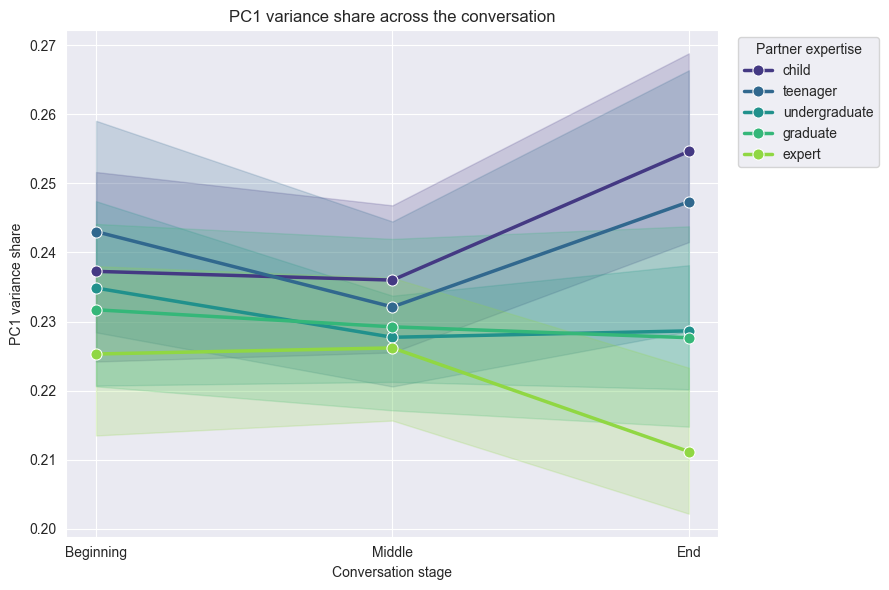

In [300]:
plot_window_development(
    window_plot_df,
    metric="pc1_variance_share",
    ylabel="PC1 variance share",
)

In [301]:
window_metric_labels = {
    "pairwise_distance_mean":
        "Mean pairwise distance",

    "pairwise_distance_sd":
        "Pairwise-distance SD",

    "radial_distance_q90":
        "Radial Q90",

    "nearest_neighbor_distance_mean":
        "Mean NN distance",

    "knn_distance_median":
        "Median kNN distance",

    "spectral_entropy_normalized":
        "Normalized spectral entropy",

    "participation_ratio":
        "Participation ratio",

    "pc1_variance_share":
        "PC1 variance share",
}

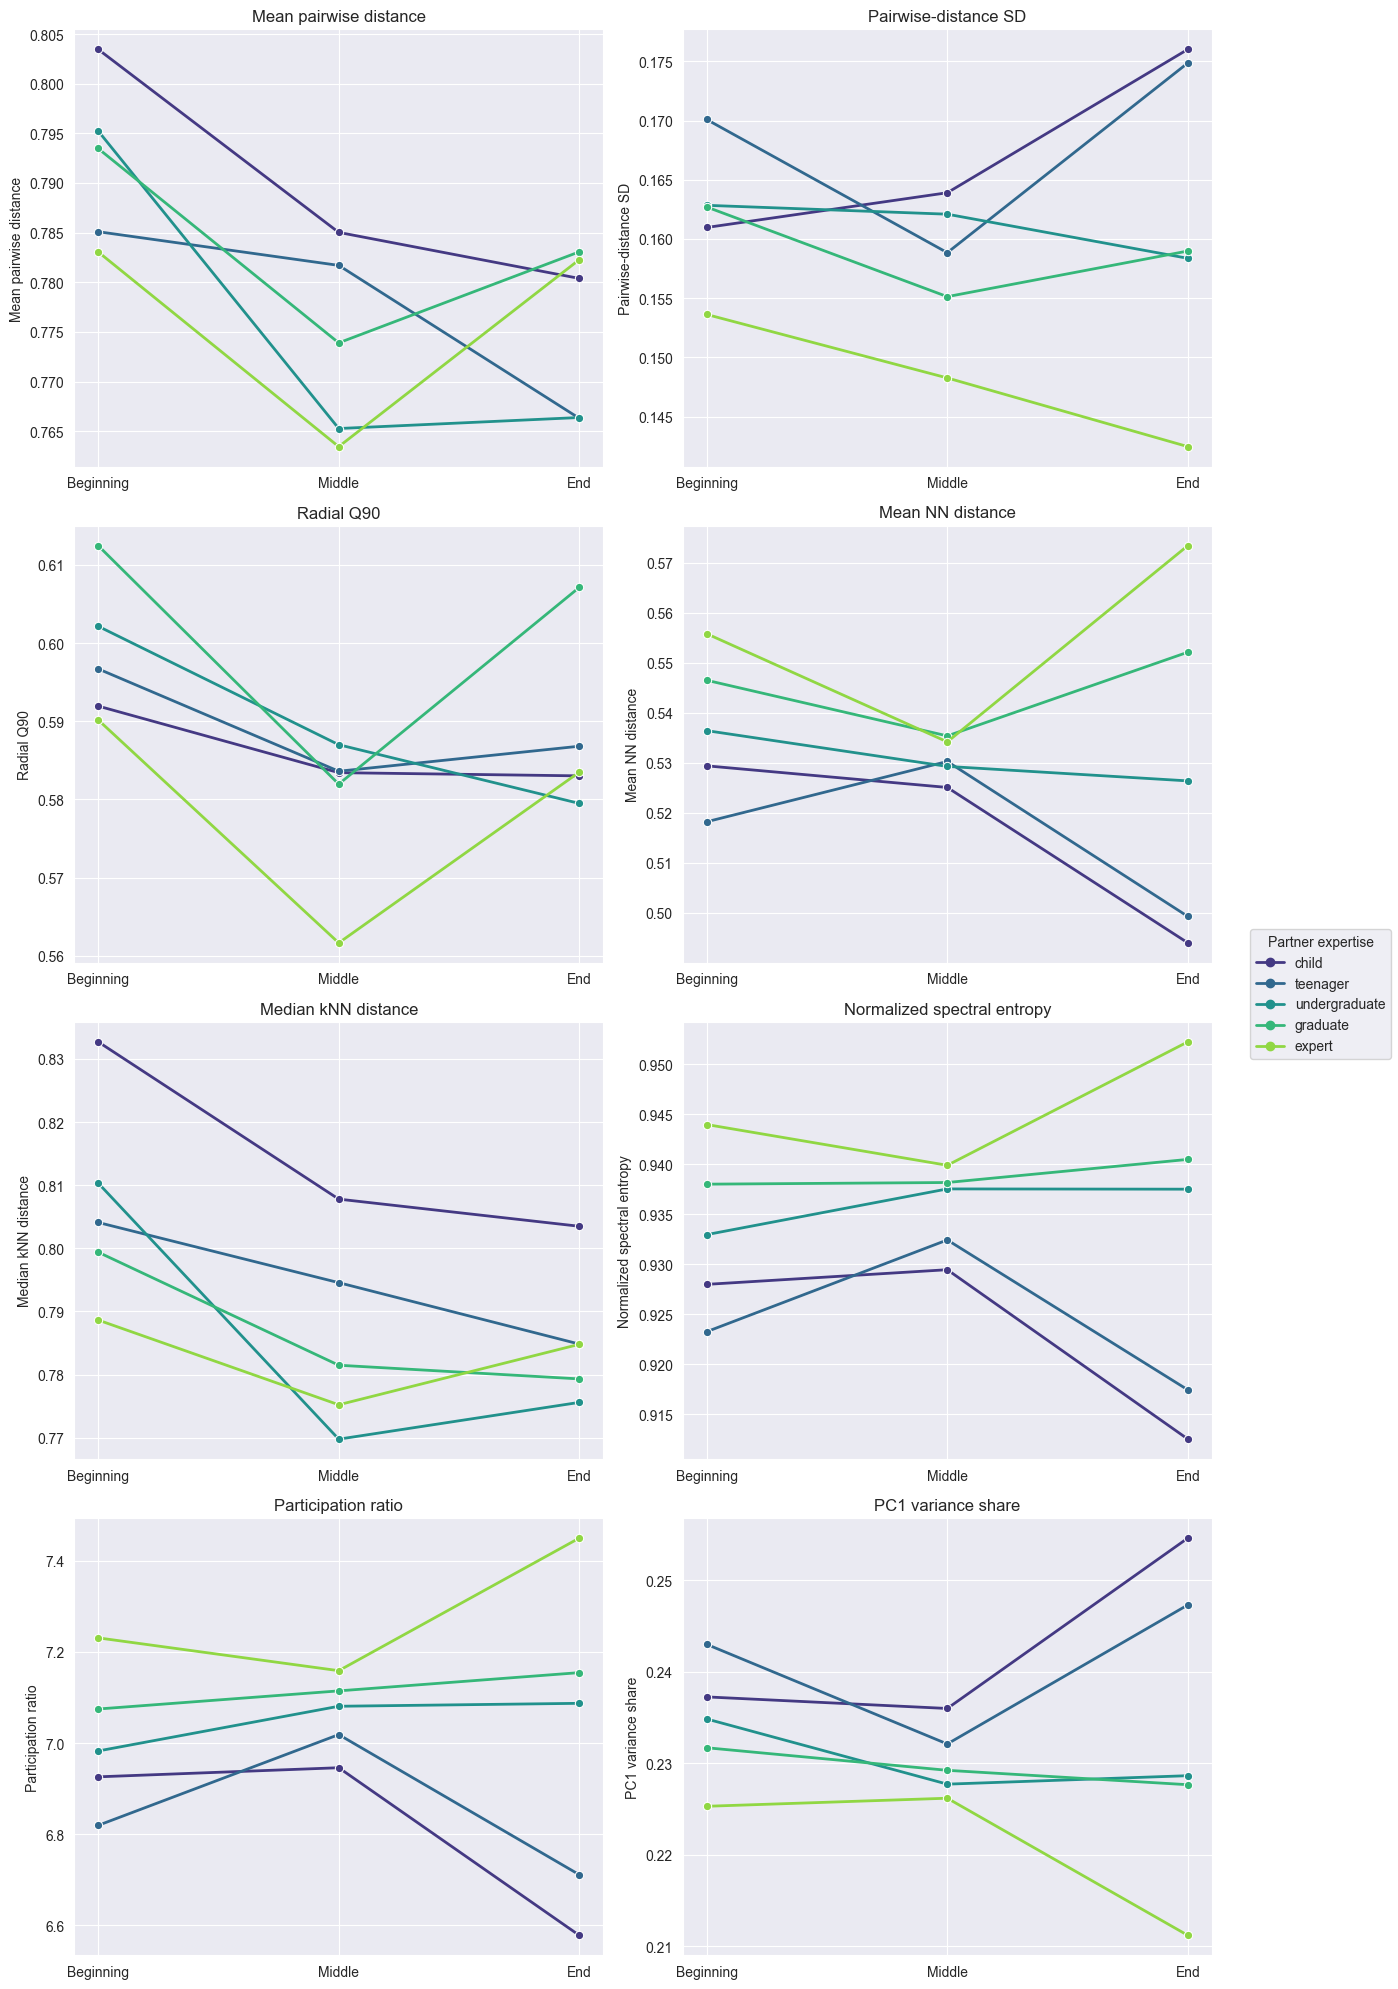

In [302]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 20),
)

axes = axes.flatten()

for ax, (metric, label) in zip(
    axes,
    window_metric_labels.items(),
):
    sns.lineplot(
        data=window_plot_df,
        x="window_index",
        y=metric,
        hue="level_label",
        hue_order=level_order,
        palette=level_palette,
        estimator="mean",
        errorbar=None,
        marker="o",
        linewidth=2,
        ax=ax,
        legend=False,
    )

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([
        "Beginning",
        "Middle",
        "End",
    ])

    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_title(label)

# One shared legend
handles = [
    plt.Line2D(
        [0],
        [0],
        color=level_palette[level],
        marker="o",
        linewidth=2,
        label=level,
    )
    for level in level_order
]

fig.legend(
    handles=handles,
    labels=level_order,
    title="Partner expertise",
    loc="center right",
)

plt.tight_layout(
    rect=[0, 0, 0.88, 1]
)

plt.show()

## individual video trajectories

In [303]:
def plot_video_window_trajectories(
    df,
    metric,
    ylabel=None,
):
    fig, axes = plt.subplots(
        1,
        5,
        figsize=(18, 4),
        sharex=True,
        sharey=True,
    )

    for ax, level in zip(
        axes,
        level_order,
    ):
        level_df = df[
            df["level_label"] == level
        ]

        for _, video_df in level_df.groupby(
            "video_group"
        ):
            video_df = video_df.sort_values(
                "window_index"
            )

            ax.plot(
                video_df["window_index"],
                video_df[metric],
                color=level_palette[level],
                alpha=0.25,
                linewidth=1,
                marker="o",
                markersize=3,
            )

        level_mean = (
            level_df
            .groupby("window_index")[metric]
            .mean()
        )

        ax.plot(
            level_mean.index,
            level_mean.values,
            color="black",
            linewidth=3,
            marker="o",
            markersize=6,
        )

        ax.set_title(level)
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([
            "Beginning",
            "Middle",
            "End",
        ], rotation=30)

    axes[0].set_ylabel(
        ylabel or metric
    )

    fig.suptitle(
        ylabel or metric,
        y=1.05,
    )

    plt.tight_layout()
    plt.show()

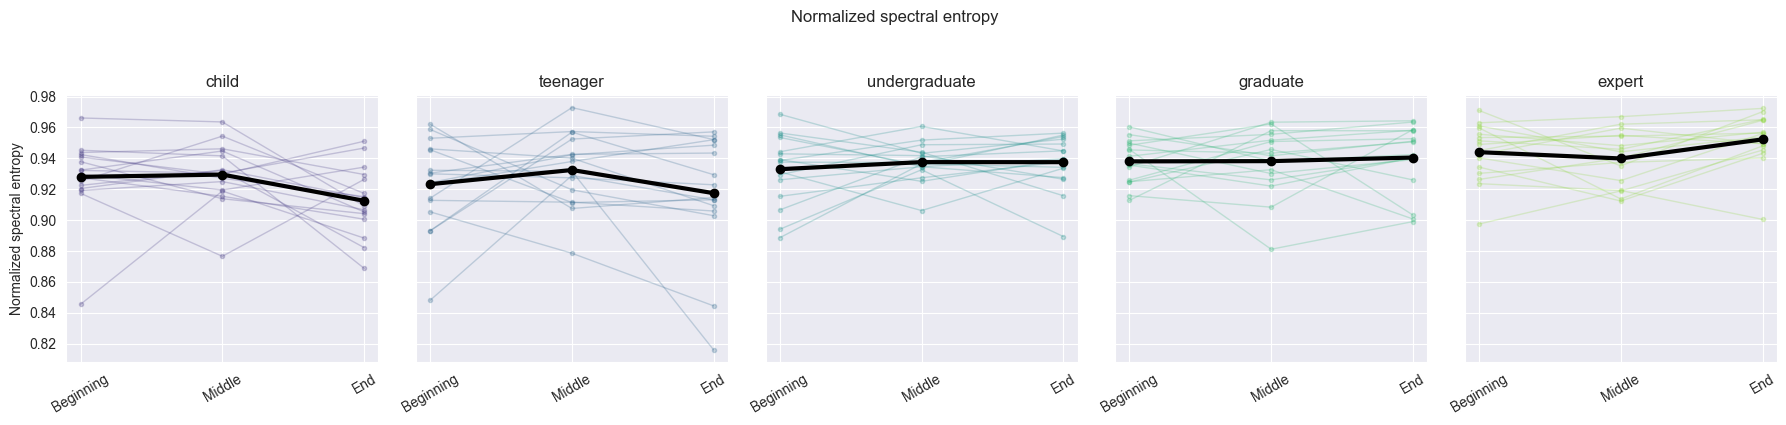

In [304]:
plot_video_window_trajectories(
    window_plot_df,
    "spectral_entropy_normalized",
    "Normalized spectral entropy",
)

In [305]:
#beginning to end changes
def calculate_window_changes(
    df,
    metric,
):
    change_df = (
        df.pivot(
            index=[
                "dataset",
                "video_id",
                "conversation_id",
                "level_label",
                "video_group",
            ],
            columns="window_index",
            values=metric,
        )
        .dropna(
            subset=[1, 3]
        )
        .reset_index()
    )

    change_df["beginning"] = (
        change_df[1]
    )

    change_df["middle"] = (
        change_df[2]
    )

    change_df["end"] = (
        change_df[3]
    )

    change_df["end_minus_beginning"] = (
        change_df["end"]
        - change_df["beginning"]
    )

    return change_df

In [306]:
def plot_beginning_end_changes(
    df,
    metric,
    ylabel=None,
):
    change_df = calculate_window_changes(
        df,
        metric,
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    sns.boxplot(
        data=change_df,
        x="level_label",
        y="end_minus_beginning",
        order=level_order,
        showfliers=False,
        color="lightgray",
        ax=ax,
    )

    sns.stripplot(
        data=change_df,
        x="level_label",
        y="end_minus_beginning",
        order=level_order,
        hue="level_label",
        hue_order=level_order,
        palette=level_palette,
        jitter=0.15,
        size=5,
        alpha=0.75,
        legend=False,
        ax=ax,
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
    )

    ax.set_xlabel(
        "Partner expertise → smaller expertise gap"
    )

    ax.set_ylabel(
        f"End − beginning\n"
        f"({ylabel or metric})"
    )

    ax.set_title(
        "Beginning-to-end geometric change"
    )

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

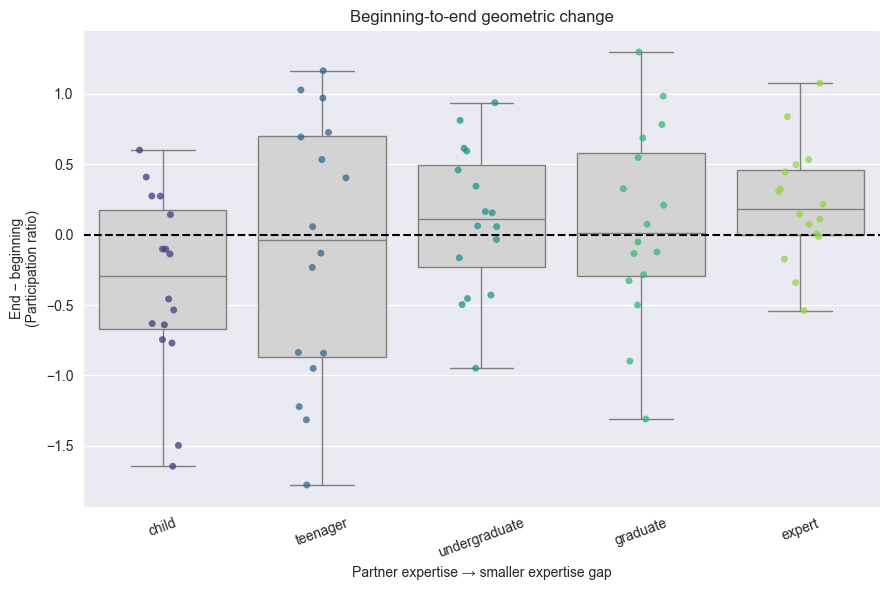

In [307]:
plot_beginning_end_changes(
    window_plot_df,
    "participation_ratio",
    "Participation ratio",
)

In [308]:
def plot_matched_change_trajectories(
    df,
    metric,
    ylabel=None,
):
    change_df = calculate_window_changes(
        df,
        metric,
    )

    level_x = {
        level: index
        for index, level in enumerate(
            level_order
        )
    }

    change_df["_level_x"] = (
        change_df["level_label"]
        .map(level_x)
    )

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    for _, video_df in change_df.groupby(
        "video_group"
    ):
        video_df = video_df.sort_values(
            "_level_x"
        )

        ax.plot(
            video_df["_level_x"],
            video_df[
                "end_minus_beginning"
            ],
            color="gray",
            alpha=0.3,
            linewidth=1,
            marker="o",
            markersize=3,
        )

    mean_change = (
        change_df
        .groupby("_level_x")[
            "end_minus_beginning"
        ]
        .mean()
        .reindex(range(5))
    )

    ax.plot(
        range(5),
        mean_change,
        color="black",
        linewidth=3,
        marker="o",
        markersize=7,
    )

    ax.axhline(
        0,
        color="red",
        linestyle="--",
    )

    ax.set_xticks(range(5))
    ax.set_xticklabels(
        level_order,
        rotation=20,
    )

    ax.set_xlabel(
        "Partner expertise → smaller expertise gap"
    )

    ax.set_ylabel(
        f"End − beginning\n"
        f"({ylabel or metric})"
    )

    ax.set_title(
        "Matched developmental changes"
    )

    plt.tight_layout()
    plt.show()

In [312]:
window_plot_df

,dataset,conversation_id,window_index,window_midpoint,time_linear,time_c,n_window_utterances,m_sampled,n_resamples_used,video_id,...,knn_distance_median_mc_sd,spectral_entropy_normalized,spectral_entropy_normalized_mc_sd,participation_ratio,participation_ratio_mc_sd,pc1_variance_share,pc1_variance_share_mc_sd,window_label,video_group,conversation_group
0,wired,wired_astro_12,1,0.166667,0.0,-0.5,19,10,200,astro,...,0.064842,0.932366,0.021338,6.917569,0.496452,0.242356,0.023375,Beginning,wired::astro,wired::wired_astro_12
1,wired,wired_astro_12,2,0.500000,0.5,0.0,19,10,200,astro,...,0.052573,0.944738,0.018306,7.295884,0.429311,0.210868,0.022205,Middle,wired::astro,wired::wired_astro_12
2,wired,wired_astro_12,3,0.833333,1.0,0.5,18,10,200,astro,...,0.116126,0.905318,0.022742,6.171352,0.530456,0.286529,0.033150,End,wired::astro,wired::wired_astro_12
3,wired,wired_astro_13,1,0.166667,0.0,-0.5,18,10,200,astro,...,0.068433,0.929994,0.013313,6.835376,0.377221,0.235565,0.027780,Beginning,wired::astro,wired::wired_astro_13
4,wired,wired_astro_13,2,0.500000,0.5,0.0,18,10,200,astro,...,0.064602,0.927368,0.010752,6.754261,0.259208,0.242629,0.018410,Middle,wired::astro,wired::wired_astro_13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,wired,wired_zero_15,2,0.500000,0.5,0.0,23,10,200,zero,...,0.060737,0.881161,0.049213,5.993723,0.823146,0.286151,0.050375,Middle,wired::zero,wired::wired_zero_15
236,wired,wired_zero_15,3,0.833333,1.0,0.5,23,10,200,zero,...,0.041657,0.899060,0.051239,6.411248,0.846812,0.271710,0.044308,End,wired::zero,wired::wired_zero_15
237,wired,wired_zero_16,1,0.166667,0.0,-0.5,36,10,200,zero,...,0.052438,0.897473,0.052062,6.465853,0.831500,0.257898,0.042814,Beginning,wired::zero,wired::wired_zero_16
238,wired,wired_zero_16,2,0.500000,0.5,0.0,36,10,200,zero,...,0.044001,0.918923,0.044573,6.842271,0.811806,0.243931,0.041933,Middle,wired::zero,wired::wired_zero_16


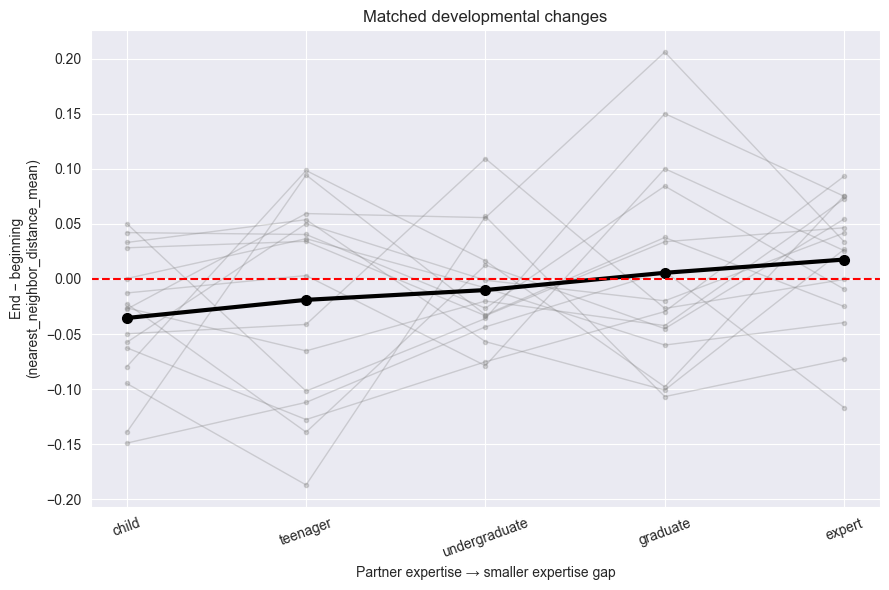

In [313]:
plot_matched_change_trajectories(window_plot_df, "nearest_neighbor_distance_mean")

In [309]:
def plot_change_heatmap(
    df,
    metric,
    label=None,
):
    change_df = calculate_window_changes(
        df,
        metric,
    )

    change_matrix = (
        change_df.pivot(
            index="video_group",
            columns="level_label",
            values="end_minus_beginning",
        )
        .reindex(columns=level_order)
    )

    # Order videos by their average change
    row_order = (
        change_matrix.mean(axis=1)
        .sort_values()
        .index
    )

    change_matrix = change_matrix.loc[
        row_order
    ]

    maximum_absolute_value = np.nanmax(
        np.abs(change_matrix.to_numpy())
    )

    plt.figure(figsize=(9, 9))

    sns.heatmap(
        change_matrix,
        cmap="coolwarm",
        center=0,
        vmin=-maximum_absolute_value,
        vmax=maximum_absolute_value,
        linewidths=0.5,
        cbar_kws={
            "label":
                "End − beginning"
        },
    )

    plt.xlabel("Partner expertise")
    plt.ylabel("Video/topic")
    plt.title(
        label or metric
    )

    plt.tight_layout()
    plt.show()

# multilevel modeling for each metric

model each metric using a mixed effect(multilevel) model. (https://pmc.ncbi.nlm.nih.gov/articles/PMC10171296/)


gap scores: 12->4 13->3 14->2 15->1 16->0

In [267]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

analysis_df = conversation_geometry.copy()

gap_map = {
    "expert": 0,
    "graduate": 1,
    "undergraduate": 2,
    "teenager": 3,
    "child": 4,
}

analysis_df["gap_score"] = (
    analysis_df["level_label"]
    .map(gap_map)
    .astype(float)
)

# Centering makes the intercept represent the middle expertise condition.
analysis_df["gap_c"] = (
    analysis_df["gap_score"]
    - analysis_df["gap_score"].mean()
)

# Use a composite identifier in case video_id is repeated across datasets.
analysis_df["video_group"] = (
    analysis_df["dataset"].astype(str)
    + "::"
    + analysis_df["video_id"].astype(str)
)

# Length variable for sensitivity analyses
analysis_df["log_n_utterances"] = np.log(
    analysis_df["n_utterances"]
)

analysis_df["log_n_utterances_c"] = (
    analysis_df["log_n_utterances"]
    - analysis_df["log_n_utterances"].mean()
)

analysis_df["level_label"] = pd.Categorical(
    analysis_df["level_label"],
    categories=[
        "expert",
        "graduate",
        "undergraduate",
        "teenager",
        "child",
    ],
    ordered=True,
)

In [268]:
#standardize outcomes
def prepare_metric(df, metric):
    model_df = df[
        [
            metric,
            "gap_score",
            "gap_c",
            "level_label",
            "video_group",
            "n_utterances",
            "log_n_utterances_c",
        ]
    ].dropna().copy()

    model_df["outcome_z"] = (
        model_df[metric] - model_df[metric].mean()
    ) / model_df[metric].std(ddof=1)

    return model_df

-> betagap represents SD change in the metric per gap level

## model 0 (null model)

separates vaience into 1: between video variance 2: within video residual variance

In [269]:
metric = "pairwise_distance_mean"
model_df = prepare_metric(analysis_df, metric)

model_0 = smf.mixedlm(
    "outcome_z ~ 1",
    data=model_df,
    groups=model_df["video_group"],
    re_formula="1",
).fit(
    reml=True,
    method="lbfgs",
)

print(model_0.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: outcome_z
No. Observations: 105     Method:             REML     
No. Groups:       21      Scale:              1.0000   
Min. group size:  5       Log-Likelihood:     -149.8966
Max. group size:  5       Converged:          Yes      
Mean group size:  5.0                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.000    0.098 -0.000 1.000 -0.191  0.191
Group Var     0.000    0.046                           



/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [270]:
#intraclass correlation
between_video_variance = model_0.cov_re.iloc[0, 0]
residual_variance = model_0.scale

icc = (
    between_video_variance
    / (between_video_variance + residual_variance)
)

print("ICC:", icc)

ICC: 4.6961693401139296e-33


icc: % unexplained variation that occurs between videos. 5 is good


## model 1 : linear expertisegap model

In [271]:
model_1 = smf.mixedlm(
    "outcome_z ~ gap_c",
    data=model_df,
    groups=model_df["video_group"],
    re_formula="1",
).fit(
    reml=True,
    method="lbfgs",
)

print(model_1.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: outcome_z
No. Observations: 105     Method:             REML     
No. Groups:       21      Scale:              0.9834   
Min. group size:  5       Log-Likelihood:     -150.2885
Max. group size:  5       Converged:          Yes      
Mean group size:  5.0                                  
--------------------------------------------------------
           Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  0.000     0.097  0.000  1.000  -0.190   0.190
gap_c      0.114     0.068  1.660  0.097  -0.021   0.248
Group Var  0.000     0.045                              



/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [272]:
beta_gap = model_1.fe_params["gap_c"]
ci_gap = model_1.conf_int().loc["gap_c"]

print("Gap coefficient:", beta_gap)
print("95% CI:", tuple(ci_gap))
print("Predicted child–expert difference:", 4 * beta_gap)

Gap coefficient: 0.11362184005460427
95% CI: (-0.020500398549797905, 0.24774407865900644)
Predicted child–expert difference: 0.45448736021841707


## model 2: length adjusted model

In [273]:
model_2 = smf.mixedlm(
    "outcome_z ~ gap_c + log_n_utterances_c",
    data=model_df,
    groups=model_df["video_group"],
    re_formula="1",
).fit(
    reml=True,
    method="lbfgs",
)

print(model_2.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  outcome_z
No. Observations:   105      Method:              REML     
No. Groups:         21       Scale:               0.6872   
Min. group size:    5        Log-Likelihood:      -140.2720
Max. group size:    5        Converged:           Yes      
Mean group size:    5.0                                    
-----------------------------------------------------------
                   Coef. Std.Err.   z   P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept          0.000    0.123 0.000 1.000 -0.240  0.240
gap_c              0.164    0.059 2.802 0.005  0.049  0.279
log_n_utterances_c 0.869    0.217 4.012 0.000  0.444  1.293
Group Var          0.178    0.138                          



/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


In [274]:
#compare gap coefficients between length adjusted and not
comparison = pd.DataFrame({
    "model": [
        "Unadjusted",
        "Length-adjusted",
    ],
    "gap_beta": [
        model_1.fe_params["gap_c"],
        model_2.fe_params["gap_c"],
    ],
    "gap_p": [
        model_1.pvalues["gap_c"],
        model_2.pvalues["gap_c"],
    ],
})

display(comparison)

,model,gap_beta,gap_p
0,Unadjusted,0.113622,0.096837
1,Length-adjusted,0.164106,0.005082


length probably doesnt have too big of an effect

## model 3: categorical expertise model

asks if each partner level differs from expert condition WITHOUT imposing linear progression

In [275]:
model_3 = smf.mixedlm(
    (
        "outcome_z ~ "
        "C(level_label, Treatment(reference='expert'))"
    ),
    data=model_df,
    groups=model_df["video_group"],
    re_formula="1",
).fit(
    reml=True,
    method="lbfgs",
)

print(model_3.summary())

                                  Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 outcome_z
No. Observations:                   105                     Method:                             REML     
No. Groups:                         21                      Scale:                              0.8995   
Min. group size:                    5                       Log-Likelihood:                     -147.4389
Max. group size:                    5                       Converged:                          No       
Mean group size:                    5.0                                                                  
---------------------------------------------------------------------------------------------------------
                                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------

/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 7.940468
  warnings.warn(msg, ConvergenceWarning)


In [276]:
from scipy.stats import chi2

model_linear_ml = smf.mixedlm(
    "outcome_z ~ gap_c",
    data=model_df,
    groups=model_df["video_group"],
    re_formula="1",
).fit(
    reml=False,
    method="lbfgs",
)

model_categorical_ml = smf.mixedlm(
    (
        "outcome_z ~ "
        "C(level_label, Treatment(reference='expert'))"
    ),
    data=model_df,
    groups=model_df["video_group"],
    re_formula="1",
).fit(
    reml=False,
    method="lbfgs",
)

lr_statistic = 2 * (
    model_categorical_ml.llf
    - model_linear_ml.llf
)

df_difference = (
    len(model_categorical_ml.fe_params)
    - len(model_linear_ml.fe_params)
)

lr_pvalue = chi2.sf(
    lr_statistic,
    df_difference,
)

print("Linear AIC:", model_linear_ml.aic)
print("Categorical AIC:", model_categorical_ml.aic)
print("Likelihood-ratio statistic:", lr_statistic)
print("Degrees of freedom:", df_difference)
print("p-value:", lr_pvalue)

Linear AIC: 302.19883919151204
Categorical AIC: 302.51491035050964
Likelihood-ratio statistic: 5.683928841002398
Degrees of freedom: 3
p-value: 0.1280422780785367


/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear

AIC values are similar - USE LINEAR MODEL FOR PARSIMONY

# model all selected metrics

In [277]:
# set of metrics to be modeled
metrics_to_model = [
    "pairwise_distance_mean",
    "pairwise_distance_sd",
    "radial_distance_q90",
    "nearest_neighbor_distance_mean",
    "knn_distance_median",
    "spectral_entropy_normalized",
    "participation_ratio",
    "pc1_variance_share",
]

linear random intercept model for each metric

In [278]:
def fit_metric_model(
    df,
    metric,
    adjust_for_length=False,
    random_slope=False,
):
    model_df = prepare_metric(df, metric)

    formula = "outcome_z ~ gap_c"

    if adjust_for_length:
        formula += " + log_n_utterances_c"

    re_formula = (
        "~gap_c"
        if random_slope
        else "1"
    )

    result = smf.mixedlm(
        formula,
        data=model_df,
        groups=model_df["video_group"],
        re_formula=re_formula,
    ).fit(
        reml=True,
        method="lbfgs",
    )

    return result

In [279]:
#run models. get gap effects
model_results = {}
summary_records = []

for metric in metrics_to_model:
    result = fit_metric_model(
        analysis_df,
        metric,
        adjust_for_length=False,
        random_slope=False,
    )

    model_results[metric] = result

    ci = result.conf_int().loc["gap_c"]

    summary_records.append({
        "metric": metric,
        "gap_beta_standardized":
            result.fe_params["gap_c"],
        "gap_se":
            result.bse["gap_c"],
        "ci_lower":
            ci.iloc[0],
        "ci_upper":
            ci.iloc[1],
        "p_value":
            result.pvalues["gap_c"],
        "converged":
            result.converged,
        "child_expert_difference_sd":
            4 * result.fe_params["gap_c"],
    })

model_summary = pd.DataFrame(summary_records)

display(model_summary)

/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/yume/PycharmProjects/horizons_2/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is s

,metric,gap_beta_standardized,gap_se,ci_lower,ci_upper,p_value,converged,child_expert_difference_sd
0,pairwise_distance_mean,0.113622,0.068431,-0.020500,0.247744,9.683678e-02,True,0.454487
1,pairwise_distance_sd,0.178246,0.057480,0.065587,0.290906,1.928699e-03,True,0.712985
2,radial_distance_q90,-0.140694,0.055168,-0.248822,-0.032566,1.076430e-02,True,-0.562776
3,nearest_neighbor_distance_mean,-0.255342,0.046575,-0.346627,-0.164057,4.196237e-08,True,-1.021367
4,knn_distance_median,0.071301,0.055400,-0.037281,0.179883,1.980848e-01,True,0.285205
5,spectral_entropy_normalized,-0.166934,0.045970,-0.257034,-0.076833,2.819703e-04,True,-0.667734
6,participation_ratio,-0.275659,0.048430,-0.370581,-0.180738,1.256349e-08,True,-1.102637
7,pc1_variance_share,0.273467,0.053384,0.168836,0.378098,3.012892e-07,True,1.093868


In [280]:
#correct for multiple testing
from statsmodels.stats.multitest import multipletests

model_summary["p_fdr_bh"] = multipletests(
    model_summary["p_value"],
    method="fdr_bh",
)[1]

model_summary["significant_fdr_05"] = (
    model_summary["p_fdr_bh"] < 0.05
)

model_summary = model_summary.sort_values(
    "p_fdr_bh"
).reset_index(drop=True)

display(model_summary)

,metric,gap_beta_standardized,gap_se,ci_lower,ci_upper,p_value,converged,child_expert_difference_sd,p_fdr_bh,significant_fdr_05
0,participation_ratio,-0.275659,0.048430,-0.370581,-0.180738,1.256349e-08,True,-1.102637,1.005079e-07,True
1,nearest_neighbor_distance_mean,-0.255342,0.046575,-0.346627,-0.164057,4.196237e-08,True,-1.021367,1.678495e-07,True
2,pc1_variance_share,0.273467,0.053384,0.168836,0.378098,3.012892e-07,True,1.093868,8.034378e-07,True
3,spectral_entropy_normalized,-0.166934,0.045970,-0.257034,-0.076833,2.819703e-04,True,-0.667734,5.639406e-04,True
4,pairwise_distance_sd,0.178246,0.057480,0.065587,0.290906,1.928699e-03,True,0.712985,3.085919e-03,True
5,radial_distance_q90,-0.140694,0.055168,-0.248822,-0.032566,1.076430e-02,True,-0.562776,1.435240e-02,True
6,pairwise_distance_mean,0.113622,0.068431,-0.020500,0.247744,9.683678e-02,True,0.454487,1.106706e-01,False
7,knn_distance_median,0.071301,0.055400,-0.037281,0.179883,1.980848e-01,True,0.285205,1.980848e-01,False


# diagnostics

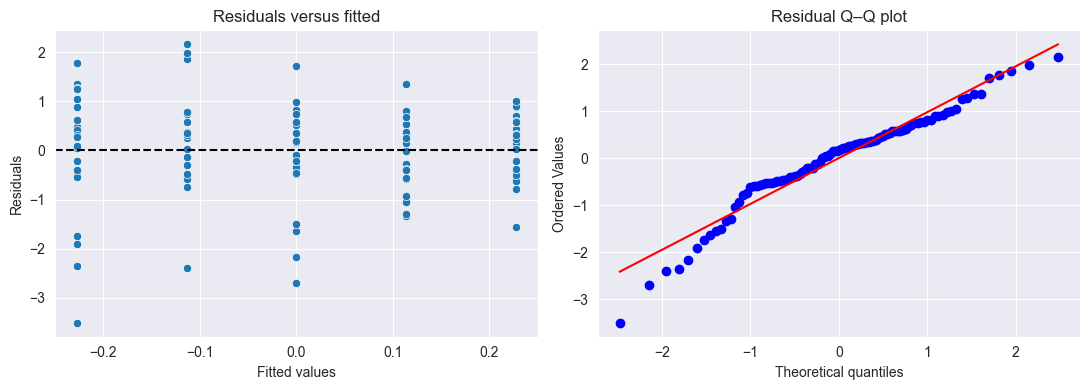

In [281]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

result = model_results["pairwise_distance_mean"]

residuals = result.resid
fitted = result.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.scatterplot(
    x=fitted,
    y=residuals,
    ax=axes[0],
)

axes[0].axhline(
    0,
    color="black",
    linestyle="--",
)

axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals versus fitted")

stats.probplot(
    residuals,
    dist="norm",
    plot=axes[1],
)

axes[1].set_title("Residual Q–Q plot")

plt.tight_layout()
plt.show()

In [282]:
model_summary

,metric,gap_beta_standardized,gap_se,ci_lower,ci_upper,p_value,converged,child_expert_difference_sd,p_fdr_bh,significant_fdr_05
0,participation_ratio,-0.275659,0.048430,-0.370581,-0.180738,1.256349e-08,True,-1.102637,1.005079e-07,True
1,nearest_neighbor_distance_mean,-0.255342,0.046575,-0.346627,-0.164057,4.196237e-08,True,-1.021367,1.678495e-07,True
2,pc1_variance_share,0.273467,0.053384,0.168836,0.378098,3.012892e-07,True,1.093868,8.034378e-07,True
3,spectral_entropy_normalized,-0.166934,0.045970,-0.257034,-0.076833,2.819703e-04,True,-0.667734,5.639406e-04,True
4,pairwise_distance_sd,0.178246,0.057480,0.065587,0.290906,1.928699e-03,True,0.712985,3.085919e-03,True
5,radial_distance_q90,-0.140694,0.055168,-0.248822,-0.032566,1.076430e-02,True,-0.562776,1.435240e-02,True
6,pairwise_distance_mean,0.113622,0.068431,-0.020500,0.247744,9.683678e-02,True,0.454487,1.106706e-01,False
7,knn_distance_median,0.071301,0.055400,-0.037281,0.179883,1.980848e-01,True,0.285205,1.980848e-01,False


larger gap -> one dominant semantic direction(this makes sense), less even spectral variation,